# 객체 탐지(YOLO26) 기반 작물 분석 실습

완숙/미숙 토마토 데이터셋으로 **Ultralytics YOLO26** 객체 탐지 모델을 학습하고,
저장된 가중치를 다시 불러와 예측·숙도 분석을 수행하는 예제입니다.

| 항목 | 내용 |
|------|------|
| 데이터 | `Ripe and Unripe Tomatoes Dataset.zip` (탐지용 이미지 177장, 객체 869개) |
| 클래스 | `0: unripe`(미숙), `1: ripe`(완숙) |
| 모델 | **YOLO26n** (`yolo26n.pt`, COCO 사전학습) |
| 환경 | **Google Colab / 로컬** 공통. NVIDIA GPU가 있으면 자동으로 GPU 사용 |

데이터 출처: [Kaggle — Riped and Unriped Tomato Dataset](https://www.kaggle.com/datasets/sumn2u/riped-and-unriped-tomato-dataset/data)

### Colab 실행 순서
1. 런타임 → 런타임 유형 변경 → **T4 GPU** 선택
2. 왼쪽 파일 패널에 zip을 업로드하거나, 아래 셀에서 업로드
3. 위에서부터 순서대로 실행

> zip 파일명에 공백이 있어도 자동으로 찾습니다.


## 0. 패키지 설치, 한글 폰트, GPU 확인

Colab은 세션마다 패키지와 한글 폰트를 다시 설치합니다.
로컬 Windows는 `맑은 고딕`을 사용합니다.

PyTorch는 설치하지 않습니다. 이미 설치된 CUDA PyTorch를 그대로 사용하고, GPU가 인식되면 학습·추론에 GPU를 씁니다.


In [1]:
# PyTorch/torchvision은 설치·업그레이드하지 않습니다. 이미 설치된 CUDA 버전을 사용합니다.
%pip install -q "ultralytics>=8.4.0" seaborn scikit-learn pandas pyyaml opencv-python-headless


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import sys
import json
import shutil
import zipfile
import warnings
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from PIL import Image, ImageDraw, ImageFont
from sklearn.model_selection import train_test_split

import torch
from ultralytics import YOLO, __version__ as ULTRALYTICS_VERSION
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)
os.environ["YOLO_VERBOSE"] = "True"

try:
    from google.colab import files, drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def setup_korean_font():
    """Colab에는 NanumGothic을 설치하고, 로컬은 OS 기본 한글 폰트를 사용합니다."""
    plt.rcParams["axes.unicode_minus"] = False
    candidates = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        "C:/Windows/Fonts/malgun.ttf",
        "C:/Windows/Fonts/malgunbd.ttf",
        "C:/Windows/Fonts/NanumGothic.ttf",
        "/System/Library/Fonts/AppleGothic.ttf",
        "/Library/Fonts/AppleGothic.ttf",
    ]
    names = ["NanumGothic", "Malgun Gothic", "AppleGothic", "NanumBarunGothic"]

    if IN_COLAB:
        import subprocess
        subprocess.run(
            ["apt-get", "-qq", "-y", "install", "fonts-nanum"],
            check=False,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        # 설치 직후 폰트 캐시를 다시 읽습니다.
        try:
            fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
        except Exception:
            pass

    for fp in candidates:
        if os.path.isfile(fp):
            try:
                fm.fontManager.addfont(fp)
            except Exception:
                pass
            family = fm.FontProperties(fname=fp).get_name()
            plt.rc("font", family=family)
            sns.set_theme(style="whitegrid", font=family)
            print(f"한글 폰트: {family}  ({fp})")
            return family

    available = {f.name for f in fm.fontManager.ttflist}
    for name in names:
        if name in available:
            plt.rc("font", family=name)
            sns.set_theme(style="whitegrid", font=name)
            print(f"한글 폰트: {name}")
            return name

    warnings.warn("한글 폰트를 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.")
    print("한글 폰트: (없음)")
    sns.set_theme(style="whitegrid")
    return None


KOREAN_FONT = setup_korean_font()


def select_compute_device():
    """Colab/로컬 공통: NVIDIA CUDA GPU가 있으면 GPU, Apple Silicon이면 MPS, 없으면 CPU."""
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = True
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        if hasattr(torch, "set_float32_matmul_precision"):
            torch.set_float32_matmul_precision("high")
        n_gpu = torch.cuda.device_count()
        name = torch.cuda.get_device_name(0)
        vram = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
        # Ultralytics는 정수 0 또는 "cuda:0" 모두 GPU로 인식합니다.
        device = 0
        print(f"연산 장치     : GPU (cuda:0)")
        print(f"GPU 이름      : {name}")
        print(f"GPU 개수      : {n_gpu}")
        print(f"VRAM          : {vram:.1f} GB")
        print(f"PyTorch CUDA  : {torch.version.cuda}")
        return device, True, name, vram

    mps = getattr(torch.backends, "mps", None)
    if mps is not None and mps.is_available():
        print("연산 장치     : Apple MPS")
        return "mps", True, "Apple MPS", 0.0

    print("연산 장치     : CPU")
    if shutil.which("nvidia-smi"):
        print("경고: nvidia-smi는 GPU를 찾았지만 현재 커널의 PyTorch가 CUDA를 쓰지 못합니다.")
        print(f"      현재 torch 빌드: {torch.__version__}")
        print("      CUDA PyTorch가 설치된 커널(인터프리터)을 선택했는지 확인하세요.")
    return "cpu", False, "CPU", 0.0


DEVICE, USE_CUDA, gpu_name, vram_gb = select_compute_device()
USE_GPU = DEVICE != "cpu"

print(f"실행 환경     : {'Google Colab' if IN_COLAB else '로컬'}")
print(f"OS            : {sys.platform}")
print(f"Ultralytics   : {ULTRALYTICS_VERSION}")
print(f"PyTorch       : {torch.__version__}")
print(f"Device 인자   : {DEVICE}")
print(f"GPU 사용      : {USE_GPU}")


def patch_cpu_torchvision_nms():
    """CPU용 torchvision에는 CUDA NMS 커널이 없어 GPU 학습이 실패합니다.
    이 경우 Ultralytics TorchNMS로 대체합니다. (PyTorch는 설치/교체하지 않음)
    """
    if not USE_CUDA:
        return
    try:
        import torchvision
        import torchvision.ops as tv_ops
    except ImportError:
        return

    try:
        boxes = torch.rand(2, 4, device="cuda")
        scores = torch.rand(2, device="cuda")
        tv_ops.nms(boxes, scores, 0.5)
        print(f"torchvision     : {torchvision.__version__} (CUDA NMS 사용 가능)")
        return
    except Exception:
        pass

    from ultralytics.utils.nms import TorchNMS

    orig_nms = tv_ops.nms

    def nms_gpu_safe(boxes, scores, iou_threshold):
        if torch.is_tensor(boxes) and boxes.is_cuda:
            return TorchNMS.nms(boxes, scores, iou_threshold)
        return orig_nms(boxes, scores, iou_threshold)

    tv_ops.nms = nms_gpu_safe
    try:
        import torchvision.ops.boxes as tv_boxes
        tv_boxes.nms = nms_gpu_safe
    except Exception:
        pass
    print(f"torchvision     : {getattr(torchvision, '__version__', '?')} (CPU 빌드)")
    print("CUDA NMS 없음  → Ultralytics TorchNMS로 대체 (학습/예측 계속 진행)")


patch_cpu_torchvision_nms()

if shutil.which("nvidia-smi"):
    import subprocess as _sp
    _sp.run(["nvidia-smi"], check=False)


한글 폰트: Malgun Gothic  (C:/Windows/Fonts/malgun.ttf)
연산 장치     : GPU (cuda:0)
GPU 이름      : NVIDIA GeForce RTX 3060
GPU 개수      : 1
VRAM          : 12.0 GB
PyTorch CUDA  : 13.0
실행 환경     : 로컬
OS            : win32
Ultralytics   : 8.4.154
PyTorch       : 2.14.0+cu130
Device 인자   : 0
GPU 사용      : True
torchvision     : 0.29.0+cpu (CPU 빌드)
CUDA NMS 없음  → Ultralytics TorchNMS로 대체 (학습/예측 계속 진행)


## 1. 데이터 zip 준비 및 압축 해제

zip 루트 구조는 다음과 같습니다.

```
detection/
├── images/                 # riped_tomato_*.jpeg, unriped_tomato_*.jpeg
├── labels/                 # YOLO txt (class xc yc w h, 정규화 좌표)
└── coco_annotations.json
segmentation/               # 본 실습에서는 사용하지 않음
```

YOLO 라벨 예시 (`riped_tomato_1.txt`):
```
1 0.446946 0.228366 0.122019 0.193065   # ripe
0 0.464426 0.636520 0.143270 0.126523   # unripe
```
한 이미지에 완숙·미숙 객체가 함께 등장할 수 있습니다.


In [3]:
# Colab에서 Google Drive를 쓰려면 True로 바꾼 뒤 zip을 드라이브에 올려 두세요.
MOUNT_DRIVE = False
ZIP_PATH = ""  # 필요하면 절대/상대 경로를 직접 지정

ROOT = Path("/content") if IN_COLAB else Path.cwd()
EXTRACT_DIR = ROOT / "tomato-data"
WORK_DIR = ROOT / "yolo_tomato"
MODEL_DIR = ROOT / "models"
RUNS_DIR = ROOT / "runs" / "detect"

CLASS_ID_TO_EN = {0: "unripe", 1: "ripe"}
CLASS_ID_TO_KO = {0: "미숙", 1: "완숙"}
CLASS_COLORS = {0: (46, 160, 46), 1: (210, 45, 45)}  # RGB
FILE_PALETTE = {"ripe": "#d22d2d", "unripe": "#2ea02e", "unknown": "#888888"}
CLS_PALETTE = {"미숙": "#2ea02e", "완숙": "#d22d2d"}


if MOUNT_DRIVE:
    if not IN_COLAB:
        raise RuntimeError("MOUNT_DRIVE=True 는 Colab에서만 사용할 수 있습니다.")
    drive.mount("/content/drive")


def find_zip_file(explicit_path=""):
    if explicit_path and os.path.isfile(explicit_path):
        return Path(explicit_path).resolve()

    search_dirs = []
    if IN_COLAB:
        search_dirs.extend([Path("/content"), Path("/content/drive/MyDrive")])
    search_dirs.extend([Path.cwd(), ROOT])

    keywords = ["tomato", "tomatoes", "ripe", "unripe", "토마토"]
    found = []
    for d in search_dirs:
        if not d.exists():
            continue
        patterns = ["*.zip", "**/*.zip"] if "MyDrive" in str(d) else ["*.zip"]
        for pat in patterns:
            found.extend([z for z in d.glob(pat) if z.is_file()])

    uniq, seen = [], set()
    for z in found:
        key = str(z.resolve())
        if key not in seen:
            seen.add(key)
            uniq.append(z)

    if not uniq:
        return None

    def score(z: Path):
        name = z.name.lower()
        return sum(1 for kw in keywords if kw in name)

    uniq = sorted(uniq, key=lambda z: (-score(z), -z.stat().st_size, z.name))
    return uniq[0].resolve()


def find_detection_root(base: Path):
    """detection/images 와 detection/labels 가 있는 폴더를 찾습니다."""
    candidates = [base, base / "detection"]
    if base.exists():
        candidates.extend([p for p in base.rglob("detection") if p.is_dir()])
    for p in candidates:
        if (p / "images").is_dir() and (p / "labels").is_dir():
            return p
        if p.name != "detection" and (p / "detection" / "images").is_dir():
            return p / "detection"
    return None


def unzip_dataset(zip_path: Path, extract_dir: Path):
    extract_dir.mkdir(parents=True, exist_ok=True)
    existing = find_detection_root(extract_dir)
    if existing is not None:
        print(f"이미 압축 해제된 데이터: {existing}")
        return existing
    print(f"압축 해제 중 → {extract_dir}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    return find_detection_root(extract_dir)


zip_path = find_zip_file(ZIP_PATH)
DET_ROOT = find_detection_root(EXTRACT_DIR)

if zip_path is None and DET_ROOT is None and IN_COLAB:
    print("zip을 찾지 못했습니다. 파일을 업로드하세요.")
    uploaded = files.upload()
    for name in uploaded:
        if name.lower().endswith(".zip"):
            zip_path = Path(name).resolve()
            break

if zip_path is not None:
    size_mb = zip_path.stat().st_size / (1024 * 1024)
    print(f"사용할 zip : {zip_path}")
    print(f"파일 크기  : {size_mb:.1f} MB")
    DET_ROOT = unzip_dataset(zip_path, EXTRACT_DIR)
elif DET_ROOT is not None:
    print("사용할 zip : (이미 압축 해제된 데이터 사용)")

if DET_ROOT is None:
    raise FileNotFoundError(
        "detection/images, detection/labels 를 찾지 못했습니다. "
        "zip을 노트북과 같은 폴더에 두거나 ZIP_PATH를 지정하세요."
    )

IMG_DIR = DET_ROOT / "images"
LBL_DIR = DET_ROOT / "labels"
print(f"탐지 데이터 루트: {DET_ROOT}")
print(f"이미지 폴더     : {IMG_DIR}")
print(f"라벨 폴더       : {LBL_DIR}")
print(f"상위 구성       : {[p.name for p in DET_ROOT.parent.iterdir()] if DET_ROOT.parent.exists() else []}")


사용할 zip : C:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(YOLO) 기반 작물 분석 실습\Ripe and Unripe Tomatoes Dataset.zip
파일 크기  : 220.8 MB
이미 압축 해제된 데이터: c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(YOLO) 기반 작물 분석 실습\tomato-data\detection
탐지 데이터 루트: c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(YOLO) 기반 작물 분석 실습\tomato-data\detection
이미지 폴더     : c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(YOLO) 기반 작물 분석 실습\tomato-data\detection\images
라벨 폴더       : c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(YOLO) 기반 작물 분석 실습\tomato-data\detection\labels
상위 구성       : ['detection', 'segmentation']


## 2. EDA — 메타데이터 구축

이미지·라벨을 짝지어 DataFrame으로 만듭니다.
파일명(`riped_` / `unriped_`)은 **사진 단위 태그**이고, txt 클래스 id는 **객체 단위 숙도**입니다.
한 장의 `riped_tomato_*.jpeg` 안에도 미숙 객체가 있을 수 있습니다.


In [4]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def parse_yolo_label(txt_path: Path):
    boxes = []
    if not txt_path.exists():
        return boxes
    text = txt_path.read_text(encoding="utf-8").strip()
    if not text:
        return boxes
    for line in text.splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        cls_id = int(float(parts[0]))
        xc, yc, w, h = map(float, parts[1:5])
        boxes.append({"cls": cls_id, "xc": xc, "yc": yc, "w": w, "h": h, "area": w * h})
    return boxes


def filename_group(stem: str):
    name = stem.lower()
    if "unriped" in name or "unripe" in name:
        return "unripe"
    if "riped" in name or "ripe" in name:
        return "ripe"
    return "unknown"


rows = []
box_rows = []
image_files = sorted([p for p in IMG_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTS])

for img_path in image_files:
    lbl_path = LBL_DIR / f"{img_path.stem}.txt"
    with Image.open(img_path) as im:
        width, height = im.size
    boxes = parse_yolo_label(lbl_path)
    cls_list = [b["cls"] for b in boxes]
    n_unripe = cls_list.count(0)
    n_ripe = cls_list.count(1)
    group = filename_group(img_path.stem)
    rows.append(
        {
            "file": img_path.name,
            "stem": img_path.stem,
            "path": str(img_path),
            "label_path": str(lbl_path),
            "width": width,
            "height": height,
            "pixels": width * height,
            "aspect": width / height if height else np.nan,
            "n_box": len(boxes),
            "n_unripe": n_unripe,
            "n_ripe": n_ripe,
            "has_both": int(n_unripe > 0 and n_ripe > 0),
            "file_group": group,
        }
    )
    for b in boxes:
        box_rows.append(
            {
                "file": img_path.name,
                "file_group": group,
                "width": width,
                "height": height,
                "cls": b["cls"],
                "cls_ko": CLASS_ID_TO_KO.get(b["cls"], str(b["cls"])),
                "xc": b["xc"],
                "yc": b["yc"],
                "bw": b["w"],
                "bh": b["h"],
                "area_norm": b["area"],
                "box_w_px": b["w"] * width,
                "box_h_px": b["h"] * height,
            }
        )

df_img = pd.DataFrame(rows)
df_box = pd.DataFrame(box_rows)

print(f"이미지 수        : {len(df_img)}")
print(f"라벨 파일 수     : {sum(Path(p).exists() for p in df_img['label_path'])}")
print(f"객체(박스) 수    : {len(df_box)}")
print(f"라벨 없는 이미지 : {int((df_img['n_box'] == 0).sum())}")
print()
display(df_img.head())
print()
display(df_img.describe(include="number").round(2))


이미지 수        : 177
라벨 파일 수     : 177
객체(박스) 수    : 869
라벨 없는 이미지 : 0



,file,stem,path,label_path,width,height,pixels,aspect,n_box,n_unripe,n_ripe,has_both,file_group
0,riped_tomato_1.jpeg,riped_tomato_1,c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(Y...,c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(Y...,350,256,89600,1.367188,15,9,6,1,ripe
1,riped_tomato_10.jpeg,riped_tomato_10,c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(Y...,c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(Y...,250,200,50000,1.250000,3,3,0,0,ripe
2,riped_tomato_11.jpeg,riped_tomato_11,c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(Y...,c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(Y...,540,324,174960,1.666667,3,0,3,0,ripe
3,riped_tomato_12.jpeg,riped_tomato_12,c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(Y...,c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(Y...,400,275,110000,1.454545,3,0,3,0,ripe
4,riped_tomato_13.jpeg,riped_tomato_13,c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(Y...,c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(Y...,791,550,435050,1.438182,5,0,5,0,ripe


,width,height,pixels,aspect,n_box,n_unripe,n_ripe,has_both
count,177.00,177.00,177.00,177.00,177.00,177.00,177.00,177.00
mean,1374.88,991.36,2532949.47,1.42,4.91,2.49,2.42,0.19
std,1335.59,910.90,6466014.57,0.27,4.15,3.14,3.49,0.39
min,250.00,200.00,50000.00,0.56,1.00,0.00,0.00,0.00
25%,631.00,440.00,277058.00,1.33,2.00,0.00,0.00,0.00
50%,971.00,675.00,667000.00,1.50,3.00,1.00,1.00,0.00
75%,1547.00,1200.00,1648000.00,1.51,6.00,4.00,4.00,0.00
max,7792.00,5200.00,40518400.00,2.00,22.00,22.00,17.00,1.00


## 3. EDA — 클래스·이미지 분포

작물 분석에서 먼저 확인할 것은 **클래스 불균형**과 **이미지당 객체 수**입니다.
수확 판정은 사진 한 장에 여러 과실이 겹쳐 있는 경우를 전제로 합니다.


파일명 그룹 (사진 태그)
file_group
ripe      97
unripe    80
Name: count, dtype: int64

객체 클래스 (박스 단위)
cls_ko
미숙    440
완숙    429
Name: count, dtype: int64

이미지당 박스 수
count    177.00
mean       4.91
std        4.15
min        1.00
25%        2.00
50%        3.00
75%        6.00
max       22.00
Name: n_box, dtype: float64

완숙+미숙 동시 등장 이미지: 33 / 177


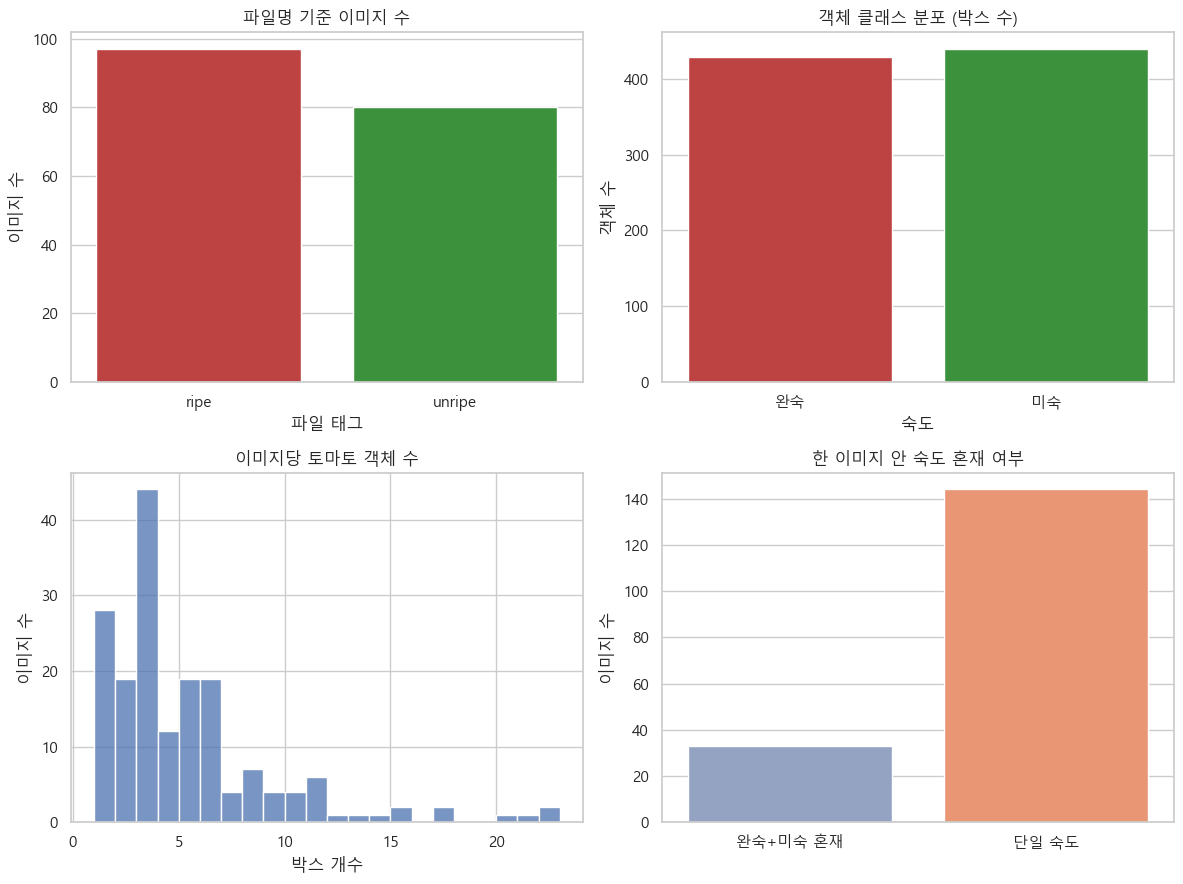

In [5]:
print("=" * 40)
print("파일명 그룹 (사진 태그)")
print(df_img["file_group"].value_counts())
print()
print("객체 클래스 (박스 단위)")
print(df_box["cls_ko"].value_counts())
print()
print("이미지당 박스 수")
print(df_img["n_box"].describe().round(2))
print()
print(f"완숙+미숙 동시 등장 이미지: {int(df_img['has_both'].sum())} / {len(df_img)}")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.countplot(data=df_img, x="file_group", hue="file_group", ax=axes[0, 0], palette=FILE_PALETTE, legend=False)
axes[0, 0].set_title("파일명 기준 이미지 수")
axes[0, 0].set_xlabel("파일 태그")
axes[0, 0].set_ylabel("이미지 수")

sns.countplot(data=df_box, x="cls_ko", hue="cls_ko", ax=axes[0, 1], palette=CLS_PALETTE, legend=False)
axes[0, 1].set_title("객체 클래스 분포 (박스 수)")
axes[0, 1].set_xlabel("숙도")
axes[0, 1].set_ylabel("객체 수")

sns.histplot(data=df_img, x="n_box", bins=range(1, int(df_img['n_box'].max()) + 2), ax=axes[1, 0], color="#4c72b0")
axes[1, 0].set_title("이미지당 토마토 객체 수")
axes[1, 0].set_xlabel("박스 개수")
axes[1, 0].set_ylabel("이미지 수")

mix_counts = df_img["has_both"].map({0: "단일 숙도", 1: "완숙+미숙 혼재"})
sns.countplot(x=mix_counts, hue=mix_counts, ax=axes[1, 1], palette=["#8da0cb", "#fc8d62"], legend=False)
axes[1, 1].set_title("한 이미지 안 숙도 혼재 여부")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("이미지 수")

plt.tight_layout()
plt.show()


## 4. EDA — 이미지 크기·박스 크기·객체 위치

원본 해상도는 비교적 작습니다. YOLO 학습 시 `imgsz=640`으로 리사이즈하므로,
작은 과실(정규화 면적이 작은 박스)이 얼마나 많은지 미리 확인합니다.


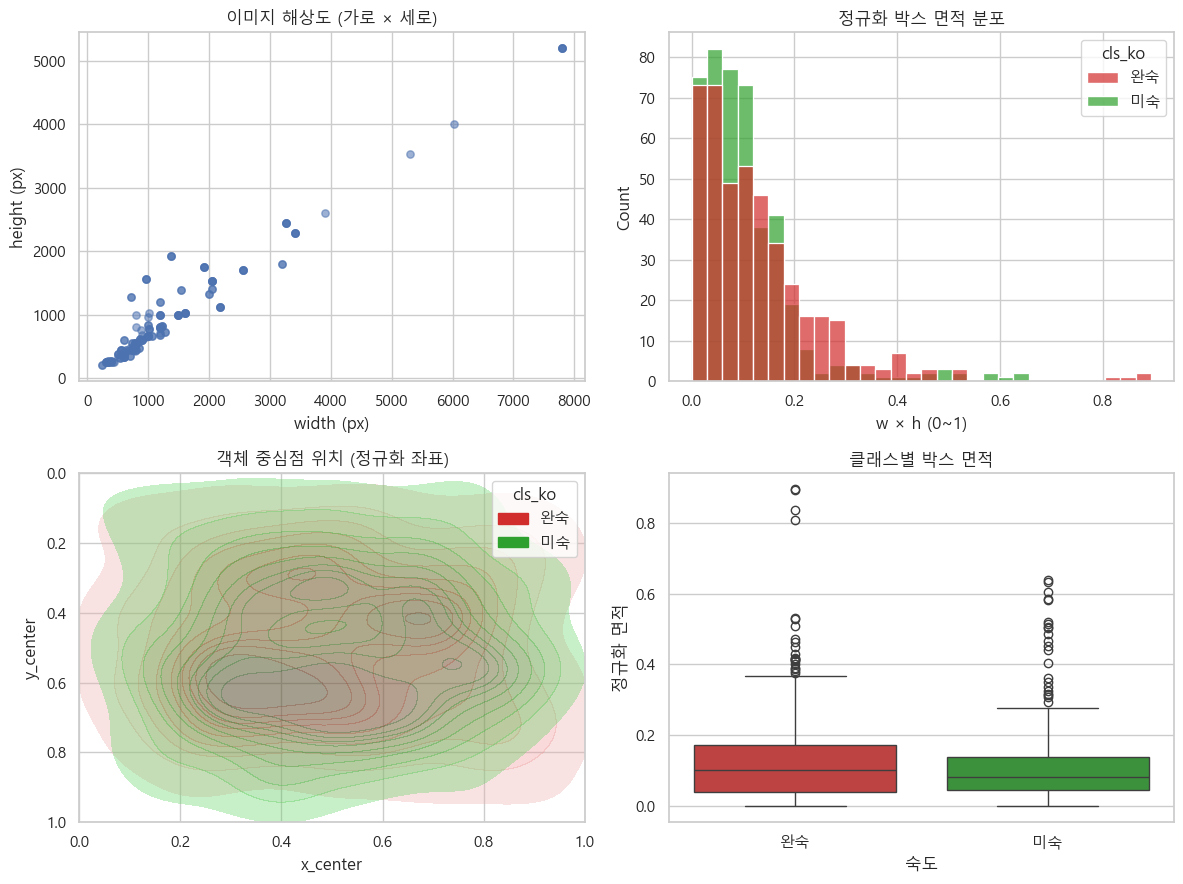

이미지 크기 요약
         width   height  aspect
count   177.00   177.00  177.00
mean   1374.88   991.36    1.42
std    1335.59   910.90    0.27
min     250.00   200.00    0.56
25%     631.00   440.00    1.33
50%     971.00   675.00    1.50
75%    1547.00  1200.00    1.51
max    7792.00  5200.00    2.00

클래스별 박스 면적(정규화) 중앙값
cls_ko
미숙    0.0833
완숙    0.1018
Name: area_norm, dtype: float64


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(df_img["width"], df_img["height"], alpha=0.55, s=28, c="#4c72b0")
axes[0, 0].set_title("이미지 해상도 (가로 × 세로)")
axes[0, 0].set_xlabel("width (px)")
axes[0, 0].set_ylabel("height (px)")

sns.histplot(data=df_box, x="area_norm", hue="cls_ko", bins=30, ax=axes[0, 1], palette=CLS_PALETTE, alpha=0.7)
axes[0, 1].set_title("정규화 박스 면적 분포")
axes[0, 1].set_xlabel("w × h (0~1)")

sns.kdeplot(data=df_box, x="xc", y="yc", hue="cls_ko", ax=axes[1, 0], fill=True, alpha=0.35, palette=CLS_PALETTE)
axes[1, 0].set_title("객체 중심점 위치 (정규화 좌표)")
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_ylim(1, 0)
axes[1, 0].set_xlabel("x_center")
axes[1, 0].set_ylabel("y_center")

sns.boxplot(data=df_box, x="cls_ko", y="area_norm", hue="cls_ko", ax=axes[1, 1], palette=CLS_PALETTE, legend=False)
axes[1, 1].set_title("클래스별 박스 면적")
axes[1, 1].set_xlabel("숙도")
axes[1, 1].set_ylabel("정규화 면적")

plt.tight_layout()
plt.show()

print("이미지 크기 요약")
print(df_img[["width", "height", "aspect"]].describe().round(2))
print()
print("클래스별 박스 면적(정규화) 중앙값")
print(df_box.groupby("cls_ko")["area_norm"].median().round(4))


## 5. EDA — 그라운드 트루스 박스 시각화

녹색 = 미숙(`unripe`), 빨강 = 완숙(`ripe`).
파일 태그와 실제 객체 클래스가 다른 경우가 있는지 눈으로 확인합니다.


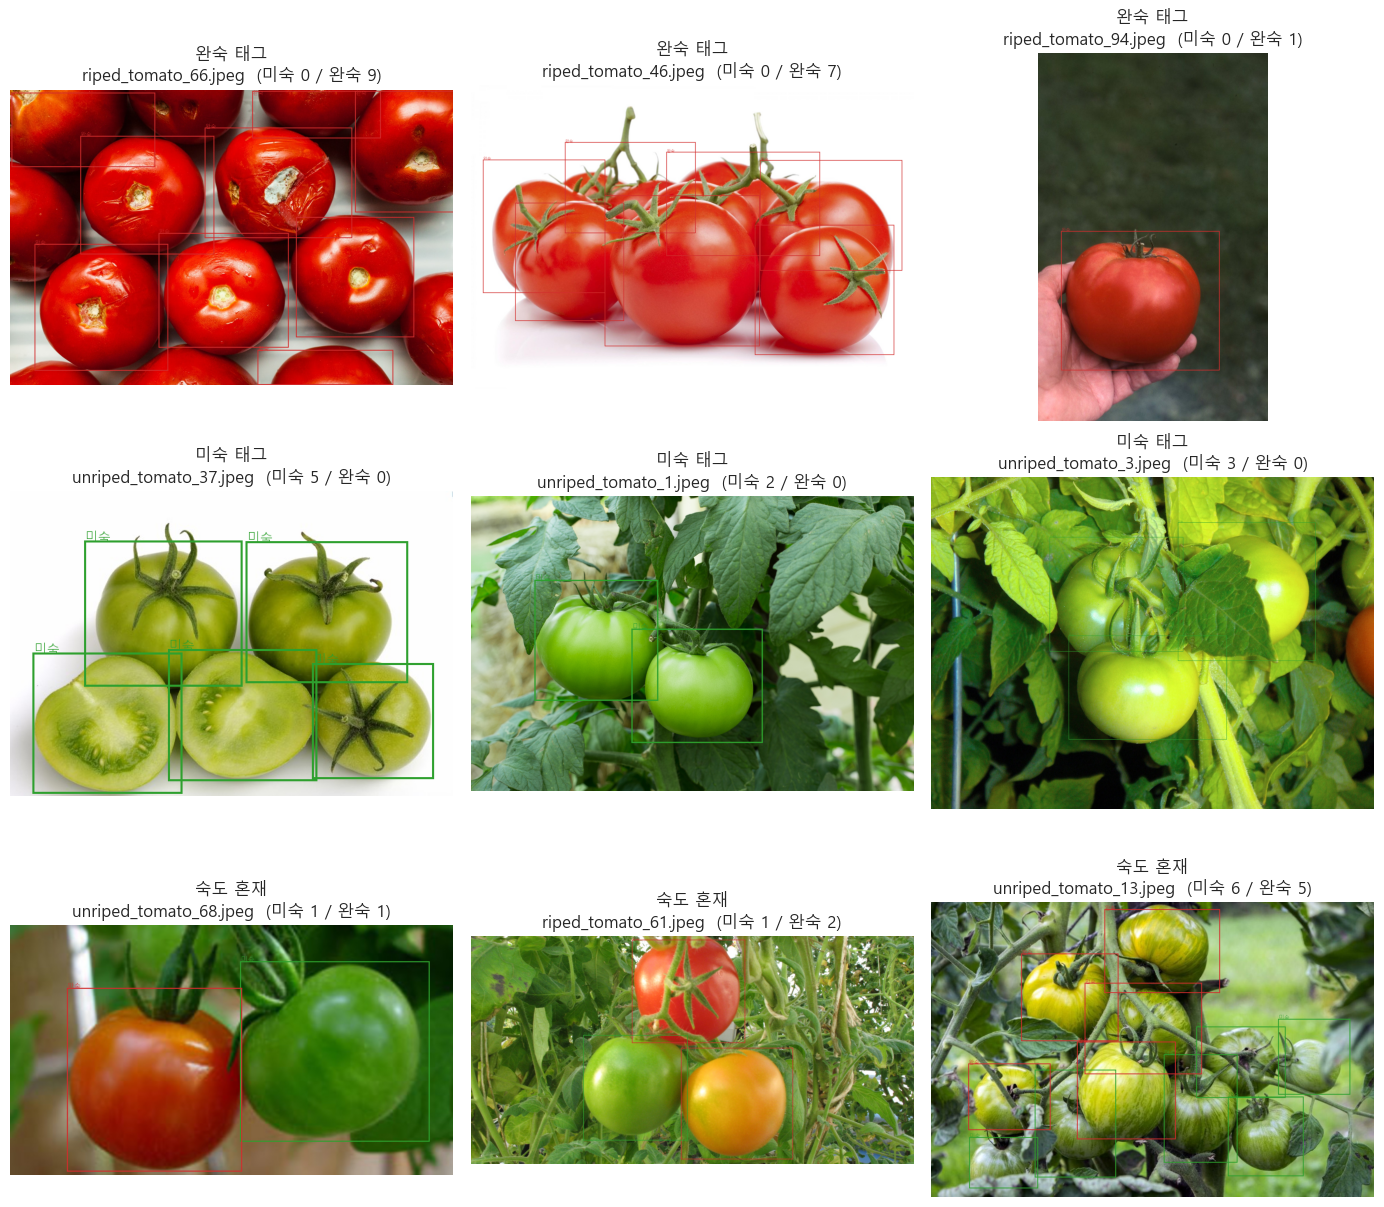

In [7]:
def load_font(size=16):
    font_files = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "C:/Windows/Fonts/malgun.ttf",
        "/System/Library/Fonts/AppleGothic.ttf",
    ]
    for fp in font_files:
        if os.path.isfile(fp):
            try:
                return ImageFont.truetype(fp, size=size)
            except Exception:
                pass
    return ImageFont.load_default()


def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    x1 = (xc - w / 2) * img_w
    y1 = (yc - h / 2) * img_h
    x2 = (xc + w / 2) * img_w
    y2 = (yc + h / 2) * img_h
    return [x1, y1, x2, y2]


def draw_gt(img_path, boxes, font):
    im = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(im)
    w, h = im.size
    for b in boxes:
        x1, y1, x2, y2 = yolo_to_xyxy(b["xc"], b["yc"], b["bw"], b["bh"], w, h)
        color = CLASS_COLORS.get(int(b["cls"]), (0, 120, 255))
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        label = CLASS_ID_TO_KO.get(int(b["cls"]), str(int(b["cls"])))
        draw.text((x1 + 2, max(0, y1 - 18)), label, fill=color, font=font)
    return im


font = load_font(18)

# 완숙 태그 / 미숙 태그 / 혼재 이미지에서 골고루 샘플
sample_groups = []
for cond, title in [
    (df_img["file_group"] == "ripe", "완숙 태그"),
    (df_img["file_group"] == "unripe", "미숙 태그"),
    (df_img["has_both"] == 1, "숙도 혼재"),
]:
    subset = df_img.loc[cond]
    if len(subset):
        sample_groups.append((title, subset.sample(n=min(3, len(subset)), random_state=42)))

n_rows = len(sample_groups)
fig, axes = plt.subplots(n_rows, 3, figsize=(14, 4.2 * n_rows))
if n_rows == 1:
    axes = np.array([axes])

for r, (title, subset) in enumerate(sample_groups):
    for c, (_, row) in enumerate(subset.iterrows()):
        boxes = df_box[df_box["file"] == row["file"]]
        vis = draw_gt(row["path"], boxes.to_dict("records"), font)
        axes[r, c].imshow(vis)
        axes[r, c].set_title(f"{title}\n{row['file']}  (미숙 {row['n_unripe']} / 완숙 {row['n_ripe']})")
        axes[r, c].axis("off")
    for c in range(len(subset), 3):
        axes[r, c].axis("off")

plt.tight_layout()
plt.show()


## 6. EDA — 객체 영역 색상 (숙도 힌트)

박스 안 픽셀의 평균 RGB를 비교합니다.
완숙 과실은 R 채널이 크고, 미숙 과실은 G 채널이 상대적으로 큰 경향이 있습니다.
이 색 차이가 YOLO가 두 클래스를 구분하는 중요한 단서입니다.


객체 크롭 평균 RGB


,R,G,B,R_ratio
cls_ko,,,,
미숙,129.07,153.24,77.21,0.36
완숙,167.33,95.10,57.90,0.54


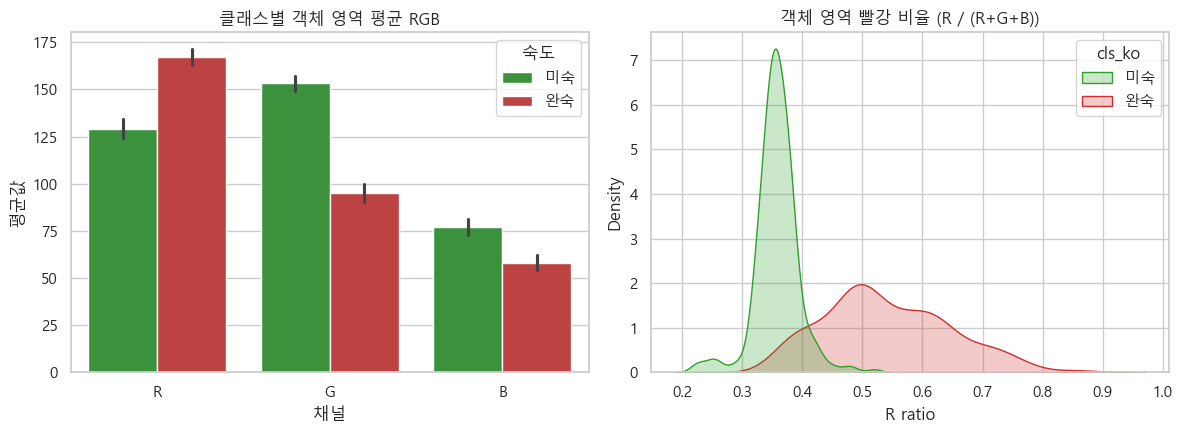

In [8]:
def crop_mean_rgb(img_path, box_row):
    im = np.array(Image.open(img_path).convert("RGB"))
    h, w = im.shape[:2]
    x1, y1, x2, y2 = yolo_to_xyxy(box_row["xc"], box_row["yc"], box_row["bw"], box_row["bh"], w, h)
    x1, y1 = max(0, int(x1)), max(0, int(y1))
    x2, y2 = min(w, int(x2)), min(h, int(y2))
    if x2 <= x1 or y2 <= y1:
        return None
    crop = im[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    mean = crop.reshape(-1, 3).mean(axis=0)
    return {"R": mean[0], "G": mean[1], "B": mean[2], "R_ratio": mean[0] / (mean.sum() + 1e-6)}


rgb_rows = []
# 전체 박스를 쓰면 시간이 걸리므로 클래스별 최대 250개만 사용
sampled_boxes = pd.concat(
    [
        g.sample(n=min(250, len(g)), random_state=0)
        for _, g in df_box.groupby("cls")
    ],
    ignore_index=True,
)
path_map = dict(zip(df_img["file"], df_img["path"]))
for _, b in sampled_boxes.iterrows():
    stats = crop_mean_rgb(path_map[b["file"]], b)
    if stats is None:
        continue
    stats["cls_ko"] = b["cls_ko"]
    rgb_rows.append(stats)

df_rgb = pd.DataFrame(rgb_rows)
print("객체 크롭 평균 RGB")
display(df_rgb.groupby("cls_ko")[["R", "G", "B", "R_ratio"]].mean().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
df_melt = df_rgb.melt(id_vars="cls_ko", value_vars=["R", "G", "B"], var_name="채널", value_name="평균값")
sns.barplot(data=df_melt, x="채널", y="평균값", hue="cls_ko", ax=axes[0], palette=CLS_PALETTE)
axes[0].set_title("클래스별 객체 영역 평균 RGB")
axes[0].legend(title="숙도")

sns.kdeplot(data=df_rgb, x="R_ratio", hue="cls_ko", fill=True, ax=axes[1], palette=CLS_PALETTE)
axes[1].set_title("객체 영역 빨강 비율 (R / (R+G+B))")
axes[1].set_xlabel("R ratio")
plt.tight_layout()
plt.show()


## 7. YOLO 학습용 데이터셋 분할

Ultralytics 권장 구조로 복사합니다.

```
yolo_tomato/
├── images/train|val|test
├── labels/train|val|test
└── data.yaml
```

비율은 train 70% / val 15% / test 15% 이며, 파일명 그룹(`ripe`/`unripe`)으로 계층 분할합니다.


In [9]:
SEED = 42
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

stems = df_img["stem"].tolist()
groups = df_img["file_group"].tolist()

train_stems, temp_stems, train_y, temp_y = train_test_split(
    stems, groups, test_size=(1 - TRAIN_RATIO), random_state=SEED, stratify=groups
)
rel_test = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
val_stems, test_stems, _, _ = train_test_split(
    temp_stems, temp_y, test_size=rel_test, random_state=SEED, stratify=temp_y
)

splits = {"train": train_stems, "val": val_stems, "test": test_stems}
print({k: len(v) for k, v in splits.items()})

if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)

stem2row = df_img.set_index("stem")
for split, split_stems in splits.items():
    (WORK_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (WORK_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)
    for stem in split_stems:
        row = stem2row.loc[stem]
        src_img = Path(row["path"])
        src_lbl = Path(row["label_path"])
        shutil.copy2(src_img, WORK_DIR / "images" / split / src_img.name)
        if src_lbl.exists():
            shutil.copy2(src_lbl, WORK_DIR / "labels" / split / src_lbl.name)

yaml_path = WORK_DIR / "data.yaml"
yaml_text = f"""# Tomato ripeness detection — YOLO26
path: {WORK_DIR.resolve().as_posix()}
train: images/train
val: images/val
test: images/test

nc: 2
names:
  0: unripe
  1: ripe
"""
yaml_path.write_text(yaml_text, encoding="utf-8")
print()
print(yaml_text)
print(f"저장: {yaml_path}")

for split in splits:
    n_img = len(list((WORK_DIR / "images" / split).glob("*.*")))
    n_lbl = len(list((WORK_DIR / "labels" / split).glob("*.txt")))
    print(f"{split:5s}  images={n_img:3d}  labels={n_lbl:3d}")


{'train': 123, 'val': 27, 'test': 27}

# Tomato ripeness detection — YOLO26
path: C:/MyCursorLab/11_농업 멀티모달 Vision 실습/03_객체 탐지(YOLO) 기반 작물 분석 실습/yolo_tomato
train: images/train
val: images/val
test: images/test

nc: 2
names:
  0: unripe
  1: ripe

저장: c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(YOLO) 기반 작물 분석 실습\yolo_tomato\data.yaml
train  images=123  labels=123
val    images= 27  labels= 27
test   images= 27  labels= 27


## 8. YOLO26 학습

COCO 사전학습 가중치 `yolo26n.pt`를 불러와 토마토 2클래스에 파인튜닝합니다.

| 설정 | 기본값 | 설명 |
|------|--------|------|
| 모델 | `yolo26n.pt` | Nano. 더 높은 정확도는 `yolo26s.pt` |
| epochs | 50 | GPU 기준 약 10~20분. 성능을 높이려면 100~150 |
| imgsz | 640 | |
| batch | GPU 16 / CPU 4 | VRAM이 부족하면 8로 낮추세요 |
| device | `0`(cuda:0) 또는 `cpu` | 로컬·Colab 모두 GPU가 있으면 자동 선택 |
| patience | 20 | 검증 성능이 개선되지 않으면 조기 종료 |

학습이 끝나면 `runs/detect/tomato_yolo26/weights/best.pt` 가 생성됩니다.


In [10]:
MODEL_NAME = "yolo26n.pt"   # 정확도를 높이려면 "yolo26s.pt"
EPOCHS = 50                 # 데모: 20  / 실습 권장: 50  / 성능: 100+
IMGSZ = 640
BATCH = 16 if USE_GPU else 4
if USE_CUDA and vram_gb and vram_gb < 8:
    BATCH = 8
PATIENCE = 20
WORKERS = 2 if IN_COLAB else 0  # Windows Jupyter는 worker 0이 안정적 (GPU 사용과 무관)

print(f"모델    : {MODEL_NAME}")
print(f"epochs  : {EPOCHS}")
print(f"imgsz   : {IMGSZ}")
print(f"batch   : {BATCH}")
print(f"device  : {DEVICE}  ({gpu_name})")
print(f"GPU사용 : {USE_GPU}")
print(f"workers : {WORKERS}")
if not USE_GPU:
    print("경고: CPU로 학습합니다. CUDA PyTorch 커널이 선택됐는지 확인하세요.")
else:
    print(f"학습은 GPU에서 진행합니다 → {gpu_name}")

train_model = YOLO(MODEL_NAME)
train_results = train_model.train(
    data=str(yaml_path),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    workers=WORKERS,
    project=str(RUNS_DIR),
    name="tomato_yolo26",
    exist_ok=True,
    patience=PATIENCE,
    plots=True,
    pretrained=True,
    optimizer="auto",
    seed=SEED,
    close_mosaic=10,
    amp=USE_GPU,
)

print()
print(f"학습 결과 폴더: {train_results.save_dir}")

# RTX 3060 12G 약 8~9분 소요

모델    : yolo26n.pt
epochs  : 50
imgsz   : 640
batch   : 16
device  : 0  (NVIDIA GeForce RTX 3060)
GPU사용 : True
workers : 0
학습은 GPU에서 진행합니다 → NVIDIA GeForce RTX 3060
Ultralytics 8.4.154  Python-3.11.9 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\MyCursorLab\11_  Vision \03_ (YOLO)    \yolo_tomato\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False,

## 9. 학습 곡선·혼동 행렬 확인


save_dir = C:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(YOLO) 기반 작물 분석 실습\runs\detect\tomato_yolo26

[results.png]


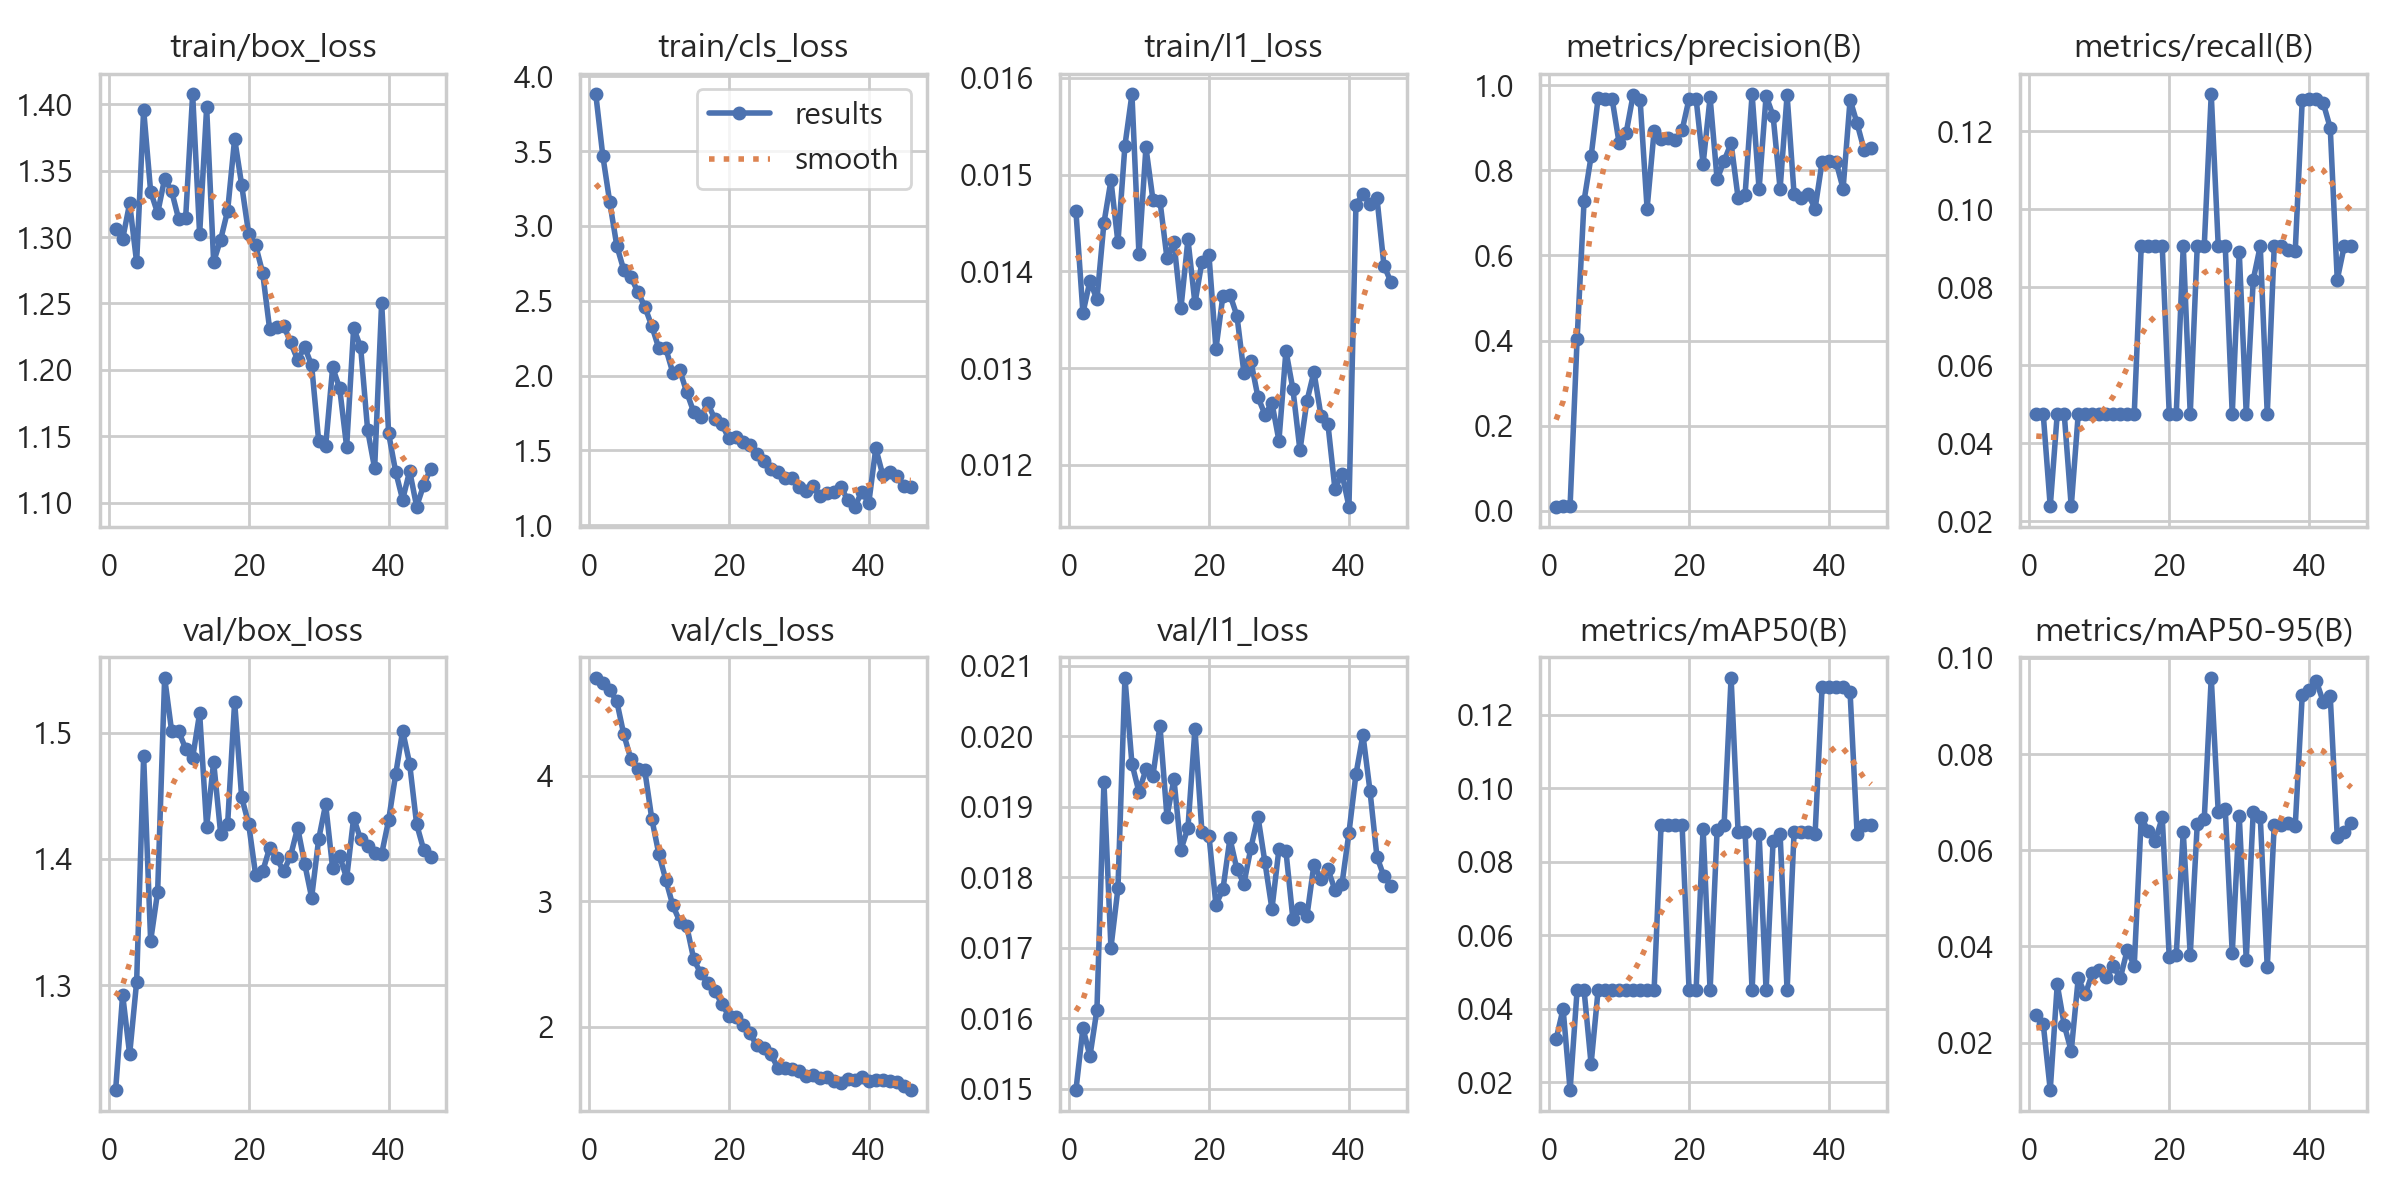


[confusion_matrix.png]


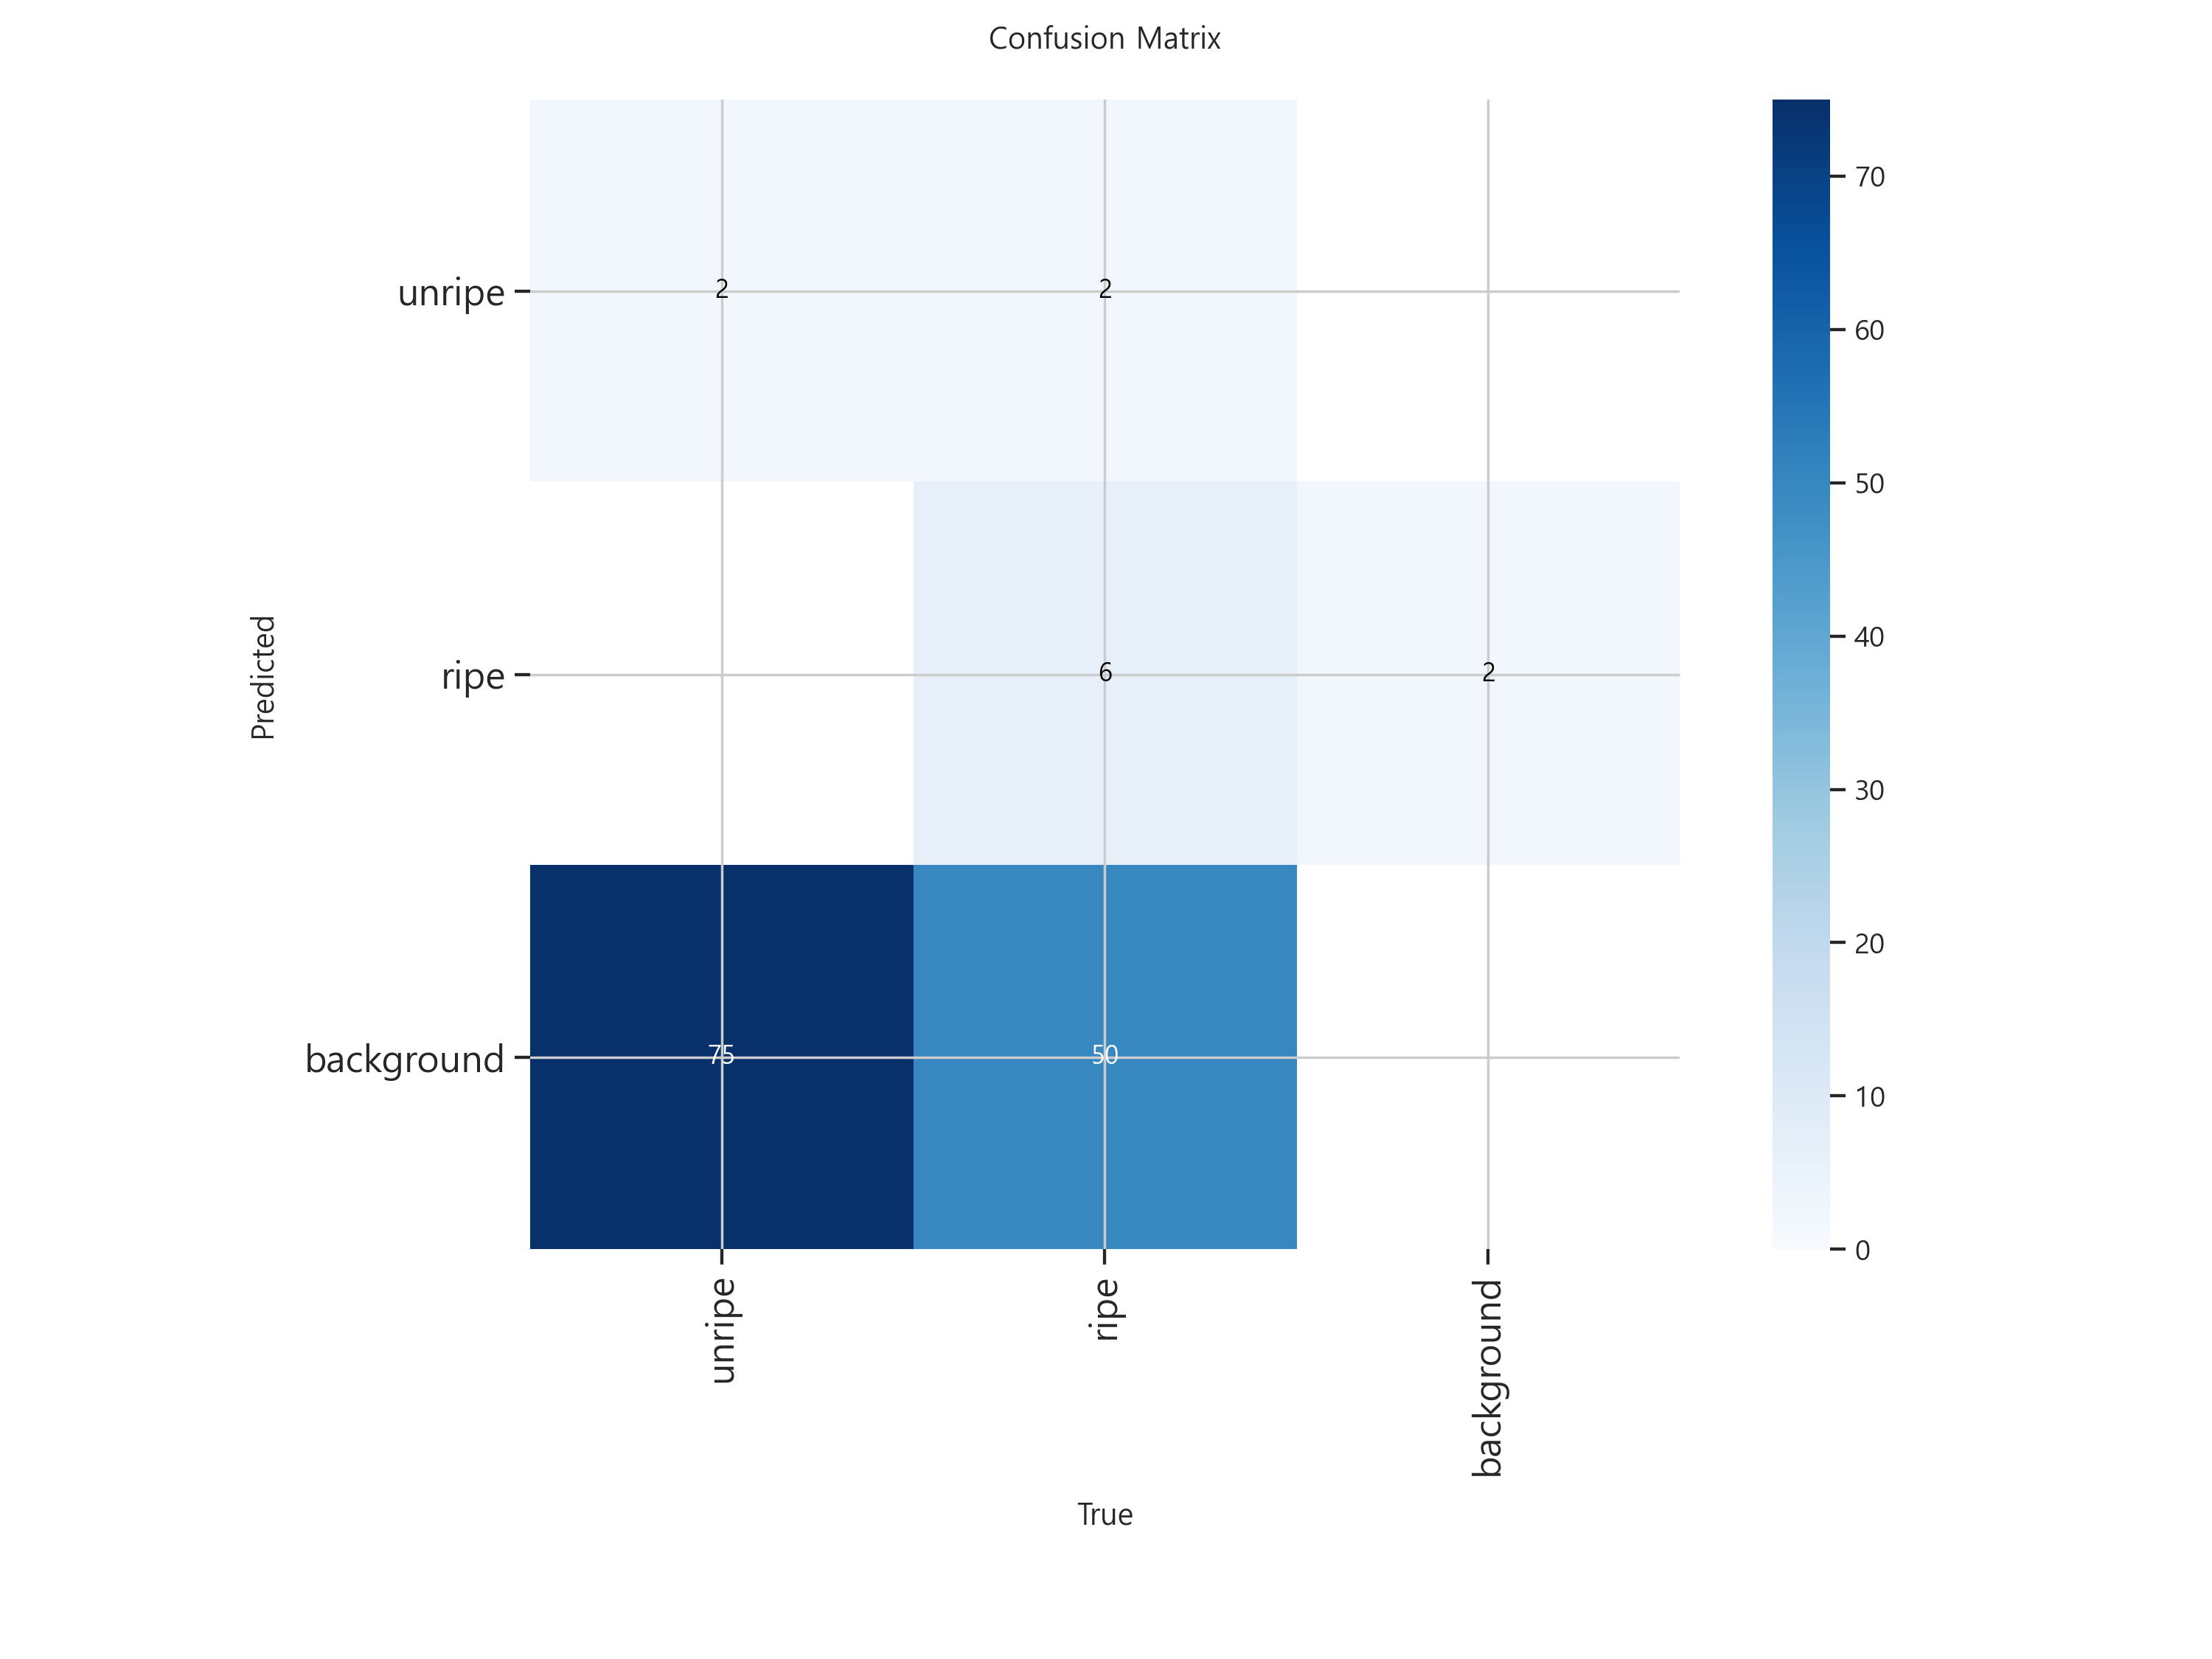


[confusion_matrix_normalized.png]


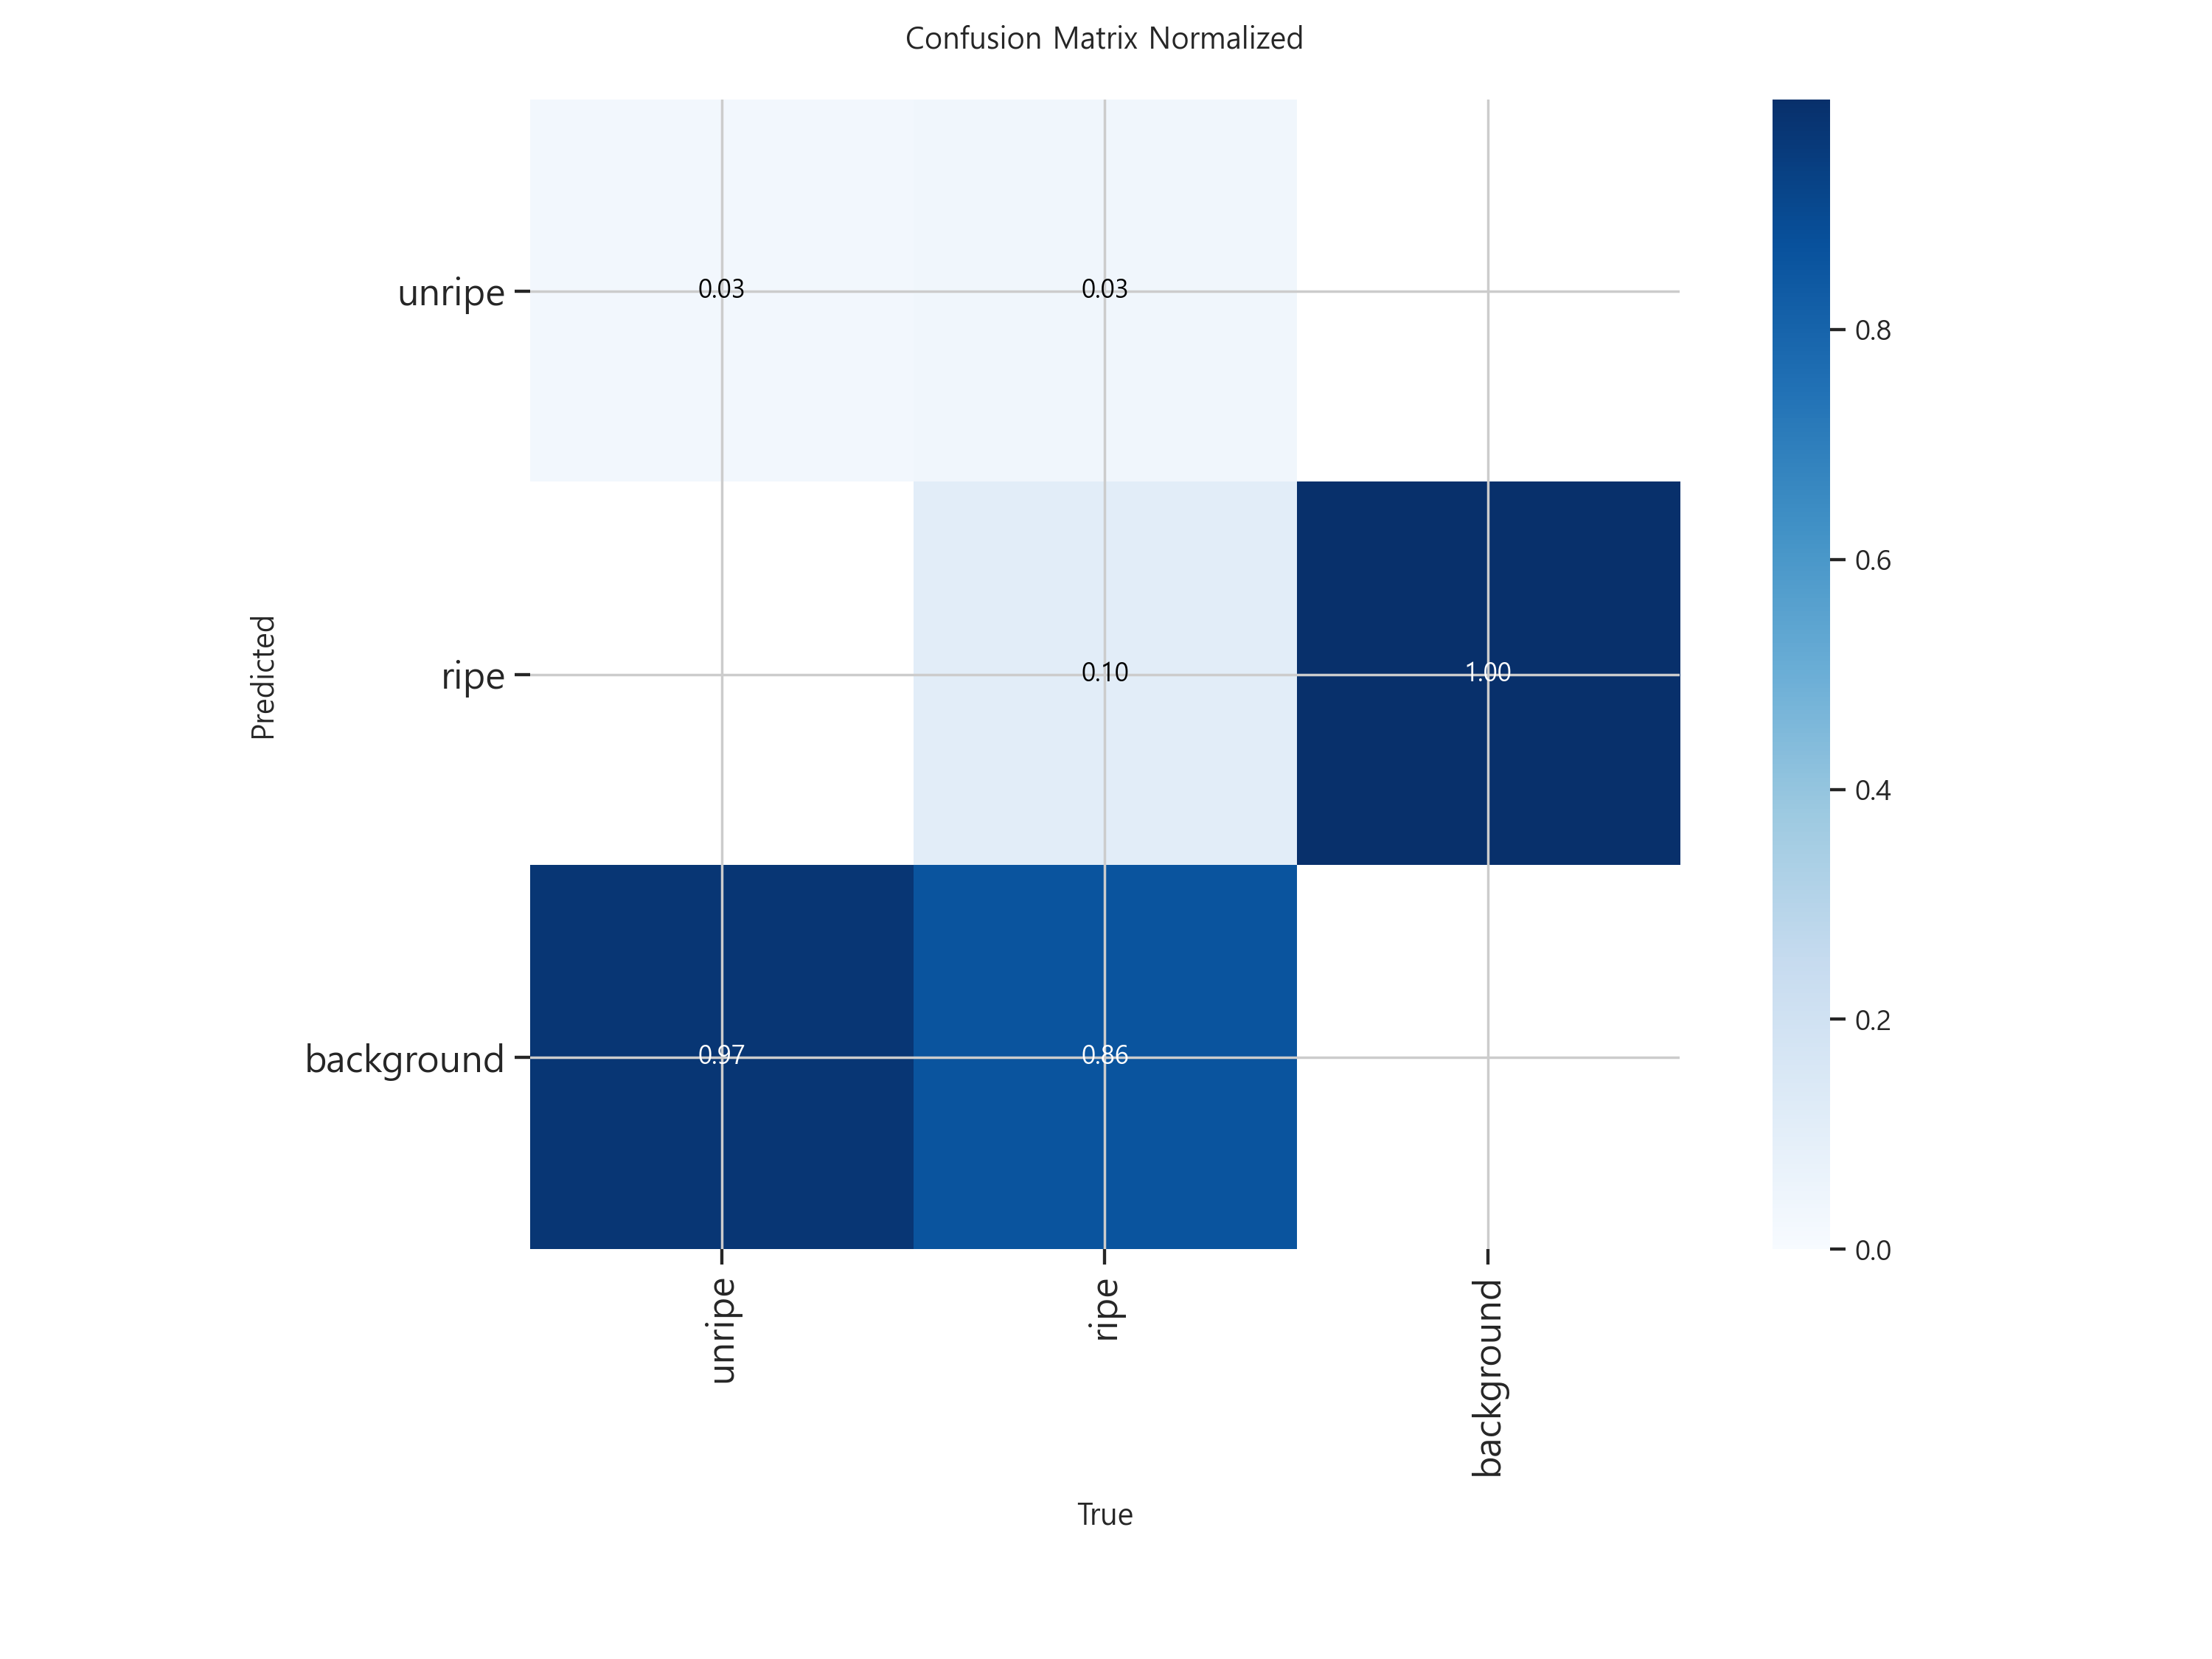

없음: F1_curve.png
없음: PR_curve.png
없음: P_curve.png
없음: R_curve.png

[labels.jpg]


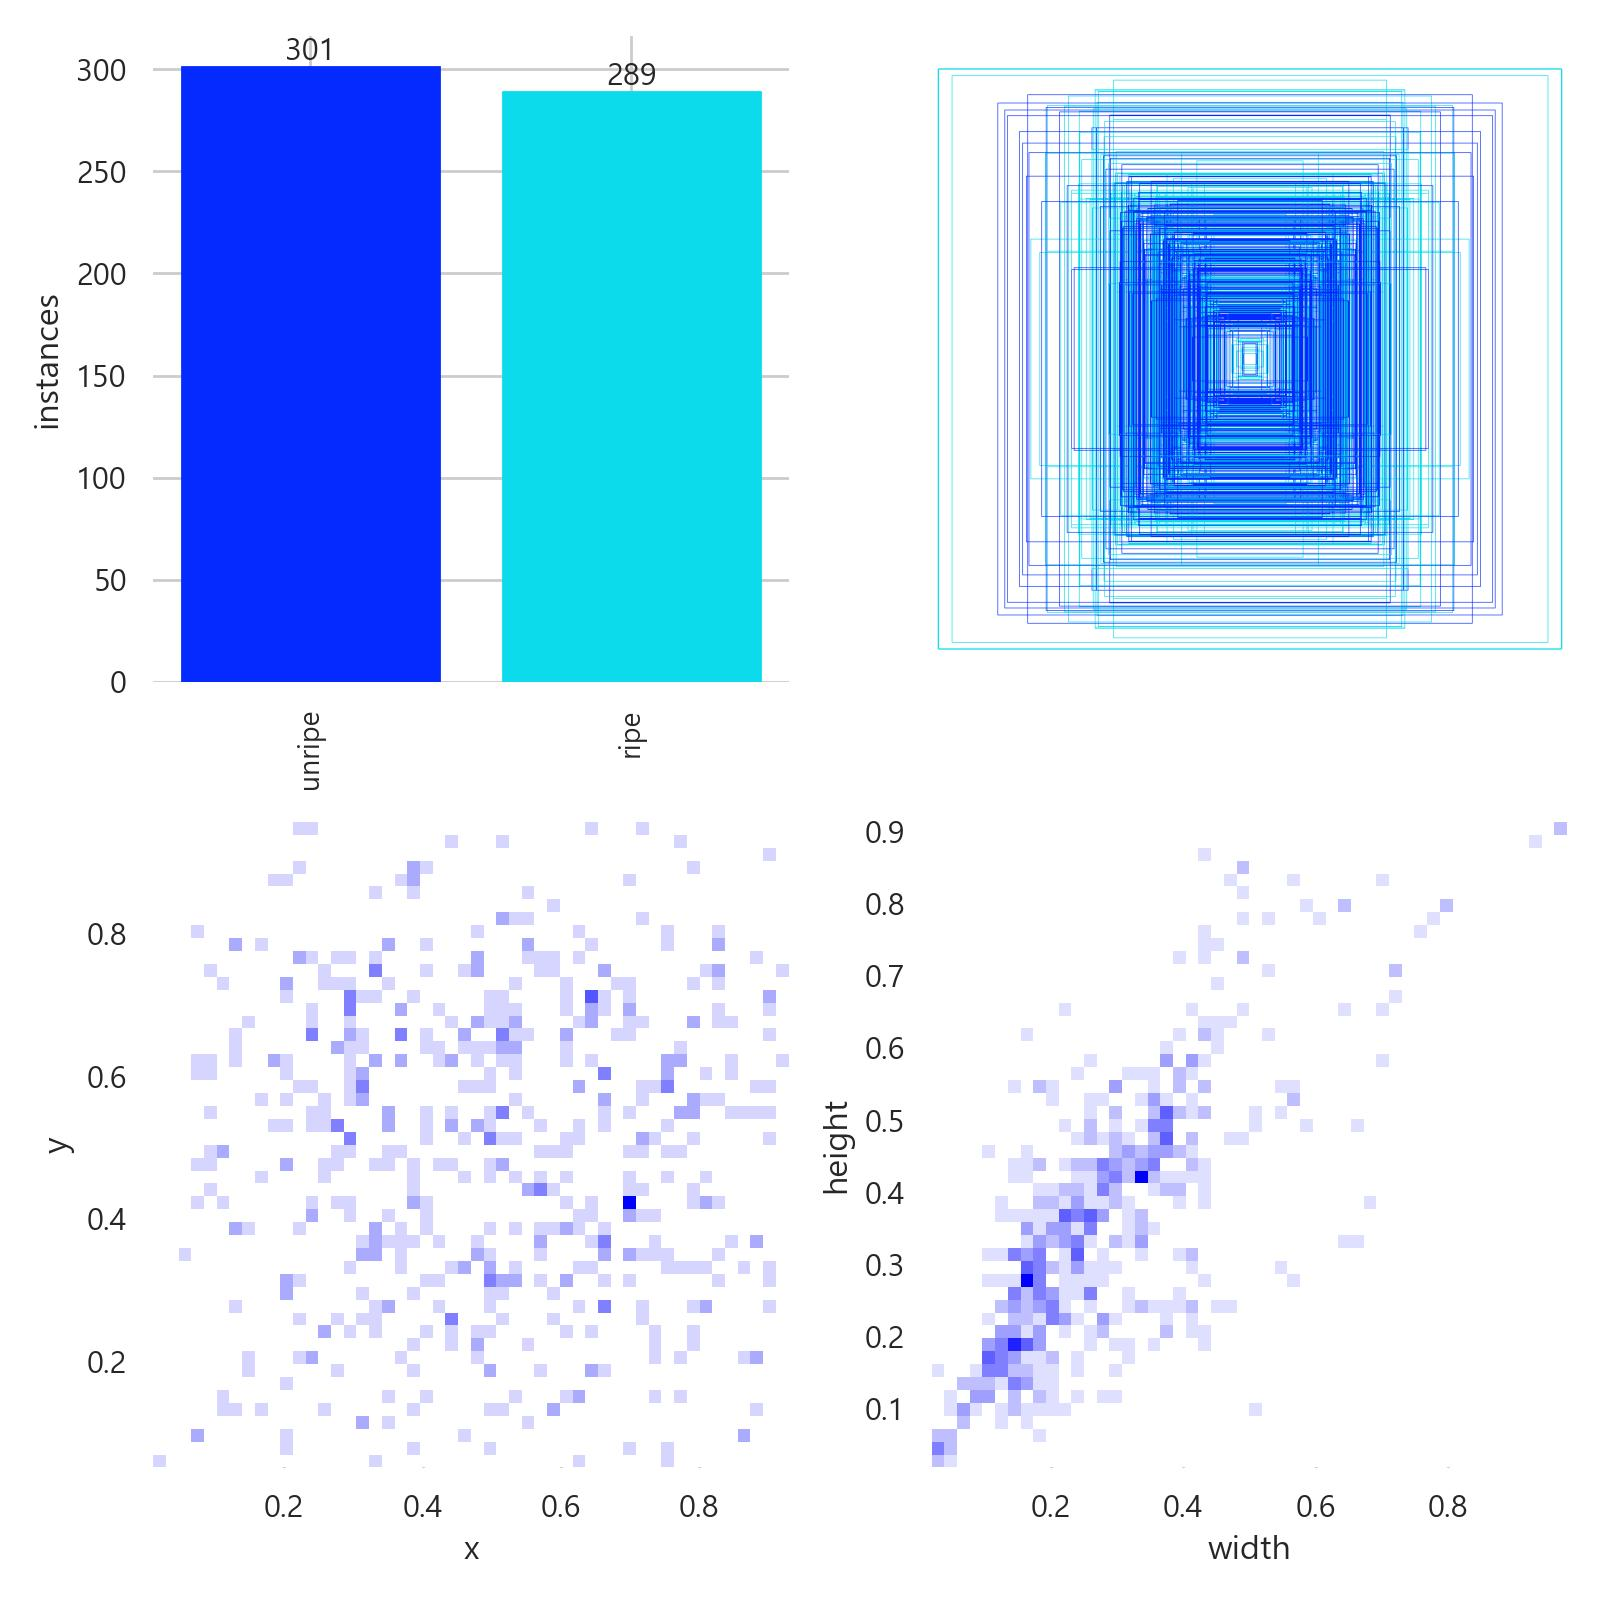

In [11]:
from IPython.display import Image as IPyImage, display

save_dir = Path(train_results.save_dir)
print(f"save_dir = {save_dir}")

plot_files = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "F1_curve.png",
    "PR_curve.png",
    "P_curve.png",
    "R_curve.png",
    "labels.jpg",
]
for name in plot_files:
    p = save_dir / name
    if p.exists():
        print(f"\n[{name}]")
        display(IPyImage(filename=str(p), width=720))
    else:
        print(f"없음: {name}")


## 10. 학습된 모델 저장

Ultralytics가 만든 `best.pt` / `last.pt`를 `models/` 폴더로 복사합니다.
이후 셀은 **이 경로의 파일만** 불러와 예측합니다.


In [12]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_src = save_dir / "weights" / "best.pt"
last_src = save_dir / "weights" / "last.pt"
SAVED_BEST = MODEL_DIR / "tomato_yolo26_best.pt"
SAVED_LAST = MODEL_DIR / "tomato_yolo26_last.pt"

if not best_src.exists():
    raise FileNotFoundError(f"best.pt 를 찾지 못했습니다: {best_src}")

shutil.copy2(best_src, SAVED_BEST)
if last_src.exists():
    shutil.copy2(last_src, SAVED_LAST)

print(f"best 복사 : {best_src}  →  {SAVED_BEST}")
print(f"best 크기 : {SAVED_BEST.stat().st_size / (1024 * 1024):.2f} MB")
if SAVED_LAST.exists():
    print(f"last 복사 : {SAVED_LAST}")

# 검증 지표 (학습 직후 메모리 모델이 아니라 저장본으로 평가)
print("\n=== 저장 모델 검증 (val) ===")
val_model = YOLO(str(SAVED_BEST))
val_metrics = val_model.val(data=str(yaml_path), imgsz=IMGSZ, device=DEVICE, split="val")
print(f"mAP50     : {float(val_metrics.box.map50):.4f}")
print(f"mAP50-95  : {float(val_metrics.box.map):.4f}")
print(f"Precision : {float(val_metrics.box.mp):.4f}")
print(f"Recall    : {float(val_metrics.box.mr):.4f}")

# Colab에서 가중치를 로컬로 받으려면 아래 주석을 해제하세요.
# if IN_COLAB:
#     files.download(str(SAVED_BEST))


best 복사 : C:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(YOLO) 기반 작물 분석 실습\runs\detect\tomato_yolo26\weights\best.pt  →  c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(YOLO) 기반 작물 분석 실습\models\tomato_yolo26_best.pt
best 크기 : 5.17 MB
last 복사 : c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(YOLO) 기반 작물 분석 실습\models\tomato_yolo26_last.pt

=== 저장 모델 검증 (val) ===
Ultralytics 8.4.154  Python-3.11.9 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLO26n summary (fused): 120 layers, 2,375,226 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1009.8661.8 MB/s, size: 3405.3 KB)
val: Scanning C:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(YOLO) 기반 작물 분석 실습\yolo_tomato\labels\val.cache... 27 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 27/27  0.0s
WARNING NMS time limit 2.800s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 50% ━━━━━━────── 1/2 24.2s/it 7.3s<24.2sWARNING NMS time limit 2.550s exceede

## 11. 저장 모델 불러와서 예측

`YOLO("models/tomato_yolo26_best.pt")` 로 가중치만 로드합니다.
test 이미지에 대해 박스를 그리고, 이미지별 미숙/완숙 개수를 집계합니다.


In [13]:
CONF = 0.25
IOU = 0.70

# 학습 객체와 분리하여, 디스크에 저장한 가중치만 사용합니다.
if "train_model" in globals():
    del train_model
if USE_CUDA:
    torch.cuda.empty_cache()

predict_model = YOLO(str(SAVED_BEST))
print(f"로드한 모델: {SAVED_BEST}")
print(f"클래스     : {predict_model.names}")

test_dir = WORK_DIR / "images" / "test"
pred_results = predict_model.predict(
    source=str(test_dir),
    conf=CONF,
    iou=IOU,
    imgsz=IMGSZ,
    device=DEVICE,
    save=True,
    project=str(RUNS_DIR),
    name="tomato_yolo26_predict",
    exist_ok=True,
    verbose=False,
)

print(f"예측 이미지 수: {len(pred_results)}")
print(f"결과 저장     : {pred_results[0].save_dir if pred_results else '(없음)'}")


로드한 모델: c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(YOLO) 기반 작물 분석 실습\models\tomato_yolo26_best.pt
클래스     : {0: 'unripe', 1: 'ripe'}
Results saved to C:\MyCursorLab\11_  Vision \03_ (YOLO)    \runs\detect\tomato_yolo26_predict
예측 이미지 수: 27
결과 저장     : C:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(YOLO) 기반 작물 분석 실습\runs\detect\tomato_yolo26_predict


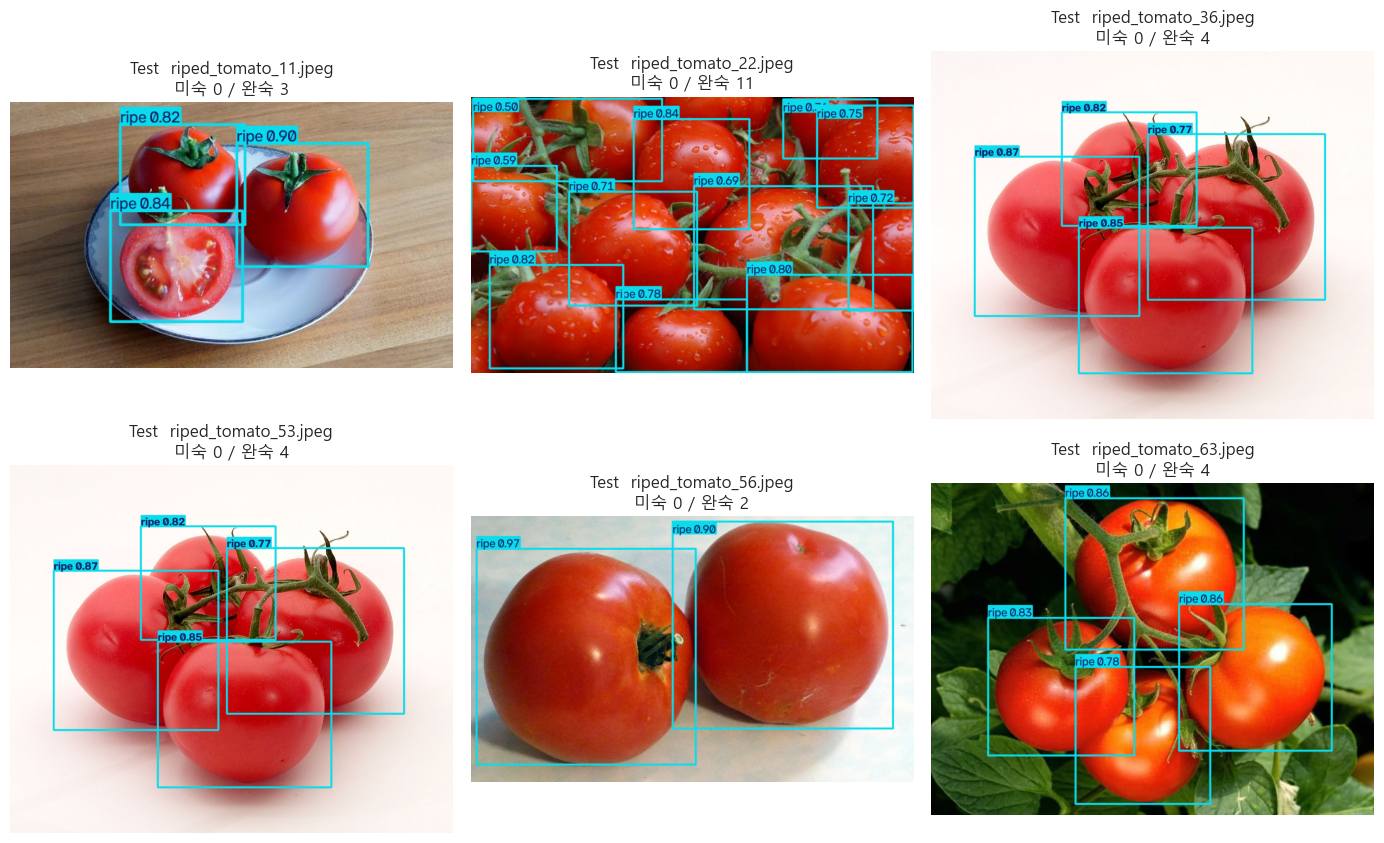

In [14]:
def show_predictions(results, n=6, title_prefix="예측"):
    n = min(n, len(results))
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4.4 * rows))
    axes = np.atleast_1d(axes).ravel()
    for i in range(n):
        r = results[i]
        annotated = r.plot()[:, :, ::-1]  # BGR → RGB
        n_unripe = int((r.boxes.cls.cpu().numpy() == 0).sum()) if r.boxes is not None else 0
        n_ripe = int((r.boxes.cls.cpu().numpy() == 1).sum()) if r.boxes is not None else 0
        axes[i].imshow(annotated)
        axes[i].set_title(f"{title_prefix}  {Path(r.path).name}\n미숙 {n_unripe} / 완숙 {n_ripe}")
        axes[i].axis("off")
    for i in range(n, len(axes)):
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()


show_predictions(pred_results, n=6, title_prefix="Test")


## 12. 작물 분석 — 숙도 비율·수확 판정

탐지 박스 개수로 이미지(또는 포장 장면)의 **완숙 비율**을 계산합니다.

- 완숙 비율 = 완숙 개수 / (미숙 + 완숙)
- 예시 기준: 70% 이상이면 `수확 권장`, 40~70%는 `부분 수확`, 그 미만은 `생육 관찰`


이미지별 탐지·숙도 분석


,file,미숙,완숙,전체,완숙비율,평균confidence,판정
0,riped_tomato_11.jpeg,0,3,3,1.000,0.854,수확 권장
1,riped_tomato_22.jpeg,0,11,11,1.000,0.682,수확 권장
2,riped_tomato_36.jpeg,0,4,4,1.000,0.825,수확 권장
3,riped_tomato_53.jpeg,0,4,4,1.000,0.825,수확 권장
4,riped_tomato_56.jpeg,0,2,2,1.000,0.936,수확 권장
5,riped_tomato_63.jpeg,0,4,4,1.000,0.832,수확 권장
7,riped_tomato_77.jpeg,0,3,3,1.000,0.784,수확 권장
9,riped_tomato_86.jpeg,0,3,3,1.000,0.871,수확 권장
8,riped_tomato_8.jpeg,0,1,1,1.000,0.915,수확 권장
10,riped_tomato_88.jpeg,0,11,11,1.000,0.682,수확 권장



=== test 세트 합계 ===
미숙 객체 : 67
완숙 객체 : 83
완숙 비율 : 0.553

판정
수확 권장    14
생육 관찰    12
부분 수확     1
Name: count, dtype: int64


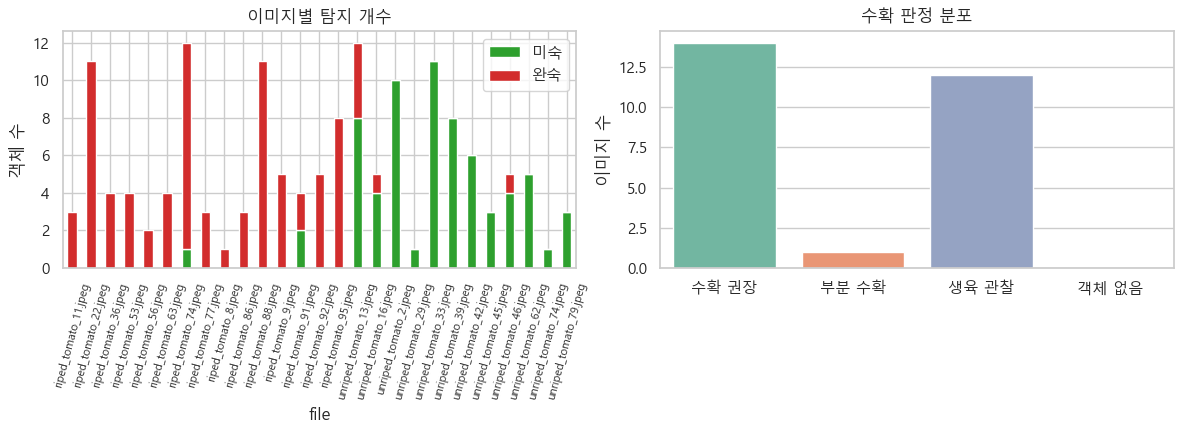

In [15]:
HARVEST_HIGH = 0.70
HARVEST_MID = 0.40


def harvest_decision(ripe_ratio):
    if np.isnan(ripe_ratio):
        return "객체 없음"
    if ripe_ratio >= HARVEST_HIGH:
        return "수확 권장"
    if ripe_ratio >= HARVEST_MID:
        return "부분 수확"
    return "생육 관찰"


records = []
for r in pred_results:
    if r.boxes is None or len(r.boxes) == 0:
        n_unripe = n_ripe = 0
        confs = np.array([])
    else:
        cls_ids = r.boxes.cls.cpu().numpy().astype(int)
        confs = r.boxes.conf.cpu().numpy()
        n_unripe = int((cls_ids == 0).sum())
        n_ripe = int((cls_ids == 1).sum())
    total = n_unripe + n_ripe
    ripe_ratio = n_ripe / total if total else np.nan
    records.append(
        {
            "file": Path(r.path).name,
            "미숙": n_unripe,
            "완숙": n_ripe,
            "전체": total,
            "완숙비율": ripe_ratio,
            "평균confidence": float(confs.mean()) if len(confs) else np.nan,
            "판정": harvest_decision(ripe_ratio),
        }
    )

df_pred = pd.DataFrame(records)
print("이미지별 탐지·숙도 분석")
display(df_pred.sort_values("완숙비율", ascending=False).round(3))

print()
print("=== test 세트 합계 ===")
print(f"미숙 객체 : {int(df_pred['미숙'].sum())}")
print(f"완숙 객체 : {int(df_pred['완숙'].sum())}")
tot = int(df_pred["전체"].sum())
print(f"완숙 비율 : {df_pred['완숙'].sum() / tot:.3f}" if tot else "완숙 비율 : N/A")
print()
print(df_pred["판정"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
df_pred.set_index("file")[["미숙", "완숙"]].plot(
    kind="bar", stacked=True, ax=axes[0], color=["#2ea02e", "#d22d2d"], legend=True
)
axes[0].set_title("이미지별 탐지 개수")
axes[0].set_ylabel("객체 수")
axes[0].tick_params(axis="x", labelrotation=75, labelsize=8)

order = ["수확 권장", "부분 수확", "생육 관찰", "객체 없음"]
sns.countplot(data=df_pred, x="판정", hue="판정", order=order, ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("수확 판정 분포")
axes[1].set_xlabel("")
axes[1].set_ylabel("이미지 수")
plt.tight_layout()
plt.show()


## 13. 단일 이미지 추론 (저장 모델 재사용)

학습을 다시 하지 않고, 저장한 `best.pt`만으로 한 장을 추론하는 패턴입니다.
현장 카메라 한 장, 또는 업로드 이미지에 그대로 적용할 수 있습니다.


샘플: c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(YOLO) 기반 작물 분석 실습\yolo_tomato\images\test\riped_tomato_11.jpeg

image 1/1 c:\MyCursorLab\11_  Vision \03_ (YOLO)    \yolo_tomato\images\test\riped_tomato_11.jpeg: 384x640 3 ripes, 24.3ms
Speed: 2.9ms preprocess, 24.3ms inference, 6.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\MyCursorLab\11_  Vision \03_ (YOLO)    \runs\detect\tomato_yolo26_single
클래스 맵: {0: 'unripe', 1: 'ripe'}


,class_id,class_en,class_ko,confidence,x1,y1,x2,y2
0,1,ripe,완숙,0.904,276.276001,50.993000,436.584015,200.408005
1,1,ripe,완숙,0.837,122.069000,132.289993,283.395996,267.420013
2,1,ripe,완숙,0.822,134.257004,27.327999,286.050995,149.955002


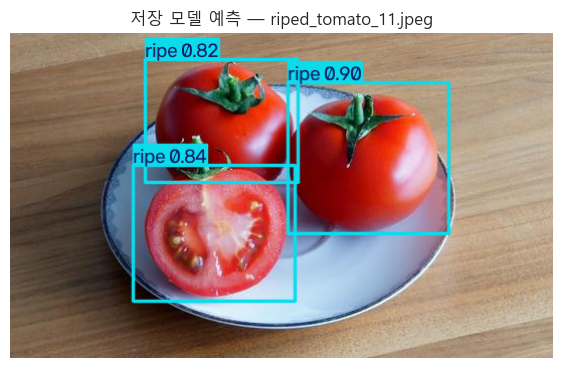


저장된 가중치 경로
  c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(YOLO) 기반 작물 분석 실습\models\tomato_yolo26_best.pt
다시 불러오는 코드
  from ultralytics import YOLO
  model = YOLO(r"c:\MyCursorLab\11_농업 멀티모달 Vision 실습\03_객체 탐지(YOLO) 기반 작물 분석 실습\models\tomato_yolo26_best.pt")
  model.predict("이미지경로.jpg", save=True)


In [16]:
# test 폴더에서 한 장을 골라 상세 결과를 출력합니다.
sample_path = sorted(test_dir.glob("*.*"))[0]
print(f"샘플: {sample_path}")

loaded = YOLO(str(SAVED_BEST))
single = loaded.predict(
    source=str(sample_path),
    conf=CONF,
    iou=IOU,
    imgsz=IMGSZ,
    device=DEVICE,
    save=True,
    project=str(RUNS_DIR),
    name="tomato_yolo26_single",
    exist_ok=True,
)[0]

print("클래스 맵:", loaded.names)
if single.boxes is not None and len(single.boxes):
    det_df = pd.DataFrame(
        {
            "class_id": single.boxes.cls.cpu().numpy().astype(int),
            "class_en": [loaded.names[int(c)] for c in single.boxes.cls.cpu().numpy()],
            "class_ko": [CLASS_ID_TO_KO[int(c)] for c in single.boxes.cls.cpu().numpy()],
            "confidence": single.boxes.conf.cpu().numpy(),
            "x1": single.boxes.xyxy[:, 0].cpu().numpy(),
            "y1": single.boxes.xyxy[:, 1].cpu().numpy(),
            "x2": single.boxes.xyxy[:, 2].cpu().numpy(),
            "y2": single.boxes.xyxy[:, 3].cpu().numpy(),
        }
    )
    display(det_df.round(3))
else:
    print("탐지된 객체가 없습니다.")

plt.figure(figsize=(7, 6))
plt.imshow(single.plot()[:, :, ::-1])
plt.title(f"저장 모델 예측 — {sample_path.name}")
plt.axis("off")
plt.show()

print()
print("저장된 가중치 경로")
print(f"  {SAVED_BEST}")
print("다시 불러오는 코드")
print('  from ultralytics import YOLO')
print(f'  model = YOLO(r"{SAVED_BEST}")')
print('  model.predict("이미지경로.jpg", save=True)')


## 정리

1. **EDA**로 클래스 균형, 이미지당 객체 수, 박스 크기, 색 차이를 확인했습니다.
2. YOLO 형식(`images/{train,val,test}` + `data.yaml`)으로 분할했습니다.
3. **YOLO26n**을 파인튜닝하고 `models/tomato_yolo26_best.pt`에 저장했습니다.
4. 저장 가중치를 `YOLO(경로)`로 로드해 test 예측과 숙도(수확) 분석을 수행했습니다.

### 성능이 낮을 때
- `EPOCHS`를 100~150으로 늘리기
- `MODEL_NAME = "yolo26s.pt"` 로 변경
- `CONF`를 0.15~0.35 사이에서 조정
- 작은 과실이 많으면 `imgsz=800` 시도 (VRAM 필요)

### Colab 팁
- 런타임이 끊기면 `models/tomato_yolo26_best.pt` 를 Drive에 복사해 두세요.
- 학습을 건너뛰고 예측만 하려면 `SAVED_BEST` 경로의 pt 파일을 만든 뒤 **11번 셀부터** 실행하면 됩니다.
